# Energy-resolved leakage and particle balance

This notebook extends the closed-box surface-current analysis from Notebook 1.5.

Notebook 1.5 calculated total neutron and photon leakage through the sides of a closed box around the full Am-Be/paraffin/cabinet geometry. In this notebook, the same idea is extended by adding energy filters to the surface-current tallies.

The purpose is to study:

* the global neutron and photon leakage balance,
* the escaped neutron and photon energy spectra,
* the energy-dependent leakage through each side of the closed box.

This gives a global, energy-resolved view of how radiation leaves the system. The results are complementary to the later local detector-point simulations, which calculate dose rates at specific measurement positions.


## 1) Setup and imports

The notebook uses the shared OpenMC geometry and source definitions from `ambe_base_model.py`.

The output folder is kept separate from Notebook 1.5, because this notebook produces energy-resolved leakage tables and spectra instead of only total leakage values.


In [ ]:
# ============================================================
# 1) Setup and imports
# ============================================================

import openmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
import importlib
import json
import shutil


# ------------------------------------------------------------
# Reload shared base model
# ------------------------------------------------------------

import ambe_base_model
importlib.reload(ambe_base_model)

print("Loaded ambe_base_model from:")
print(ambe_base_model.__file__)


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

OUTPUT_DIR = Path("N1_6_energy_resolved_leakage_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, METADATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print()
print("Output folders:")
print(f"  {OUTPUT_DIR}")
print(f"  {TABLE_DIR}")
print(f"  {FIGURE_DIR}")
print(f"  {METADATA_DIR}")


# ------------------------------------------------------------
# Run settings
# ------------------------------------------------------------

RUN_OPENMC = False  # Set to False to reload existing statepoints instead of running OpenMC
# Set RUN_OPENMC = True when you are ready to run the simulations.
# With RUN_OPENMC = False, the notebook will try to reload existing statepoints.

RUN_BATCHES = 300
RUN_PARTICLES = 100_000

print()
print("Run settings:")
print(f"  RUN_OPENMC   = {RUN_OPENMC}")
print(f"  batches      = {RUN_BATCHES}")
print(f"  particles    = {RUN_PARTICLES}")
print(f"  histories    = {RUN_BATCHES * RUN_PARTICLES:.3e}")

Loaded ambe_base_model from:
/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/ambe_base_model.py

Output folders:
  N1_6_energy_resolved_leakage_outputs
  N1_6_energy_resolved_leakage_outputs/tables
  N1_6_energy_resolved_leakage_outputs/figures
  N1_6_energy_resolved_leakage_outputs/metadata

Run settings:
  RUN_OPENMC   = True
  batches      = 300
  particles    = 100000
  histories    = 3.000e+07


## 2) Source strengths and energy bins

The neutron source strength is the physical Am-Be neutron emission rate used throughout the simulation notebooks.

The photon source strength is obtained from the ALPHANSO gamma-line model. It is scaled relative to the neutron source so that the neutron and photon leakage rates can both be expressed in physical units.

Energy bins are defined separately for neutron and photon leakage spectra.


In [14]:
# ============================================================
# 2) Source strengths and energy bins
# ============================================================

SOURCE_NEUTRON_EMISSION = 1.2e7  # n/s


# ------------------------------------------------------------
# Gamma source strength from ALPHANSO gamma-line model
# ------------------------------------------------------------

gamma_energy_dist, gamma_data = ambe_base_model.build_ambe_gamma_line_distribution(
    make_plot=False,
    verbose=True,
)

gamma_yield = float(gamma_data["gamma_yield"])

alphanso_results = gamma_data.get("alphanso_results", {})


def find_first_numeric_value(data, candidate_keys):
    """
    Try to find a numerical value in a dictionary using several possible keys.
    """

    for key in candidate_keys:
        if isinstance(data, dict) and key in data:
            try:
                return float(data[key])
            except Exception:
                pass

    return None


alphanso_neutron_yield = find_first_numeric_value(
    alphanso_results,
    [
        "total_yield",
        "total_neutron_yield",
        "neutron_yield",
        "total_alpha_n_yield",
        "Total (alpha,n) yield",
    ],
)

if alphanso_neutron_yield is None:
    # Fallback from the ALPHANSO printout used in Notebook 1
    alphanso_neutron_yield = 4.268e6
    print()
    print("Warning:")
    print("  Could not extract total ALPHANSO neutron yield automatically.")
    print(f"  Using fallback value: {alphanso_neutron_yield:.3e} n/s/g")

GAMMA_PER_NEUTRON_RATIO = gamma_yield / alphanso_neutron_yield
GAMMA_SOURCE_EMISSION = SOURCE_NEUTRON_EMISSION * GAMMA_PER_NEUTRON_RATIO

print()
print("Source scaling:")
print(f"  Physical neutron source strength: {SOURCE_NEUTRON_EMISSION:.3e} n/s")
print(f"  ALPHANSO neutron yield:          {alphanso_neutron_yield:.3e} n/s/g")
print(f"  ALPHANSO gamma yield:            {gamma_yield:.3e} photons/s/g")
print(f"  Gamma/neutron source ratio:      {GAMMA_PER_NEUTRON_RATIO:.6f}")
print(f"  Physical gamma source strength:  {GAMMA_SOURCE_EMISSION:.3e} photons/s")


# ------------------------------------------------------------
# Energy bins
# ------------------------------------------------------------

# Neutron leakage spectrum:
# from thermal/epithermal region to above the Am-Be endpoint.
NEUTRON_ENERGY_BINS_EV = np.logspace(-3, 7.3, 121)

# Photon leakage spectrum:
# from low-energy scattered photons to above the 4.4389 MeV line.
PHOTON_ENERGY_BINS_EV = np.logspace(3, 7.3, 101)

print()
print("Energy bins:")
print(
    f"  Neutron: {NEUTRON_ENERGY_BINS_EV[0]:.3e} eV "
    f"to {NEUTRON_ENERGY_BINS_EV[-1]:.3e} eV "
    f"({len(NEUTRON_ENERGY_BINS_EV)-1} bins)"
)
print(
    f"  Photon:  {PHOTON_ENERGY_BINS_EV[0]:.3e} eV "
    f"to {PHOTON_ENERGY_BINS_EV[-1]:.3e} eV "
    f"({len(PHOTON_ENERGY_BINS_EV)-1} bins)"
)

Am-Be gamma emission lines:
  Total gamma yield: 2.783366e+06
  E = 3.2138 MeV, yield = 1.559798e+02, probability = 0.005604 %
  E = 4.4389 MeV, yield = 2.783210e+06, probability = 99.994396 %

Dominant gamma line:
  E = 4.4389 MeV
  probability = 99.994396 %

  Could not extract total ALPHANSO neutron yield automatically.
  Using fallback value: 4.268e+06 n/s/g

Source scaling:
  Physical neutron source strength: 1.200e+07 n/s
  ALPHANSO neutron yield:          4.268e+06 n/s/g
  ALPHANSO gamma yield:            2.783e+06 photons/s/g
  Gamma/neutron source ratio:      0.652148
  Physical gamma source strength:  7.826e+06 photons/s

Energy bins:
  Neutron: 1.000e-03 eV to 1.995e+07 eV (120 bins)
  Photon:  1.000e+03 eV to 1.995e+07 eV (100 bins)


## 3) Build energy-resolved surface-current models

The same closed-box surface-current setup as Notebook 1.5 is reused. The difference is that an energy filter is added to the surface-current tally.

This gives a two-dimensional tally result:

```text
box side × energy bin
```

for each particle type.


In [15]:
# ============================================================
# 3) Build energy-resolved surface-current models
# ============================================================

SCENARIOS = {
    "full_geometry": {
        "include_cabinet": True,
        "include_lead": True,
    },
}

PARTICLE_CONFIGS = {
    "neutron": {
        "energy_bins_eV": NEUTRON_ENERGY_BINS_EV,
        "source_strength": SOURCE_NEUTRON_EMISSION,
    },
    "photon": {
        "energy_bins_eV": PHOTON_ENERGY_BINS_EV,
        "source_strength": GAMMA_SOURCE_EMISSION,
    },
}


def build_base_surface_current_model_flexible(
    scenario_name,
    particle,
    batches,
    particles,
):
    """
    Build the base surface-current model from ambe_base_model.py.
    """

    scenario = SCENARIOS[scenario_name]

    call_attempts = [
        {
            "include_cabinet": scenario["include_cabinet"],
            "include_lead": scenario["include_lead"],
            "particle": particle,
            "batches": batches,
            "particles": particles,
        },
        {
            "include_cabinet": scenario["include_cabinet"],
            "include_lead": scenario["include_lead"],
            "particle": particle,
        },
        {
            "particle": particle,
        },
    ]

    last_error = None

    for kwargs in call_attempts:
        try:
            return ambe_base_model.build_surface_current_model(**kwargs)
        except TypeError as err:
            last_error = err

    raise TypeError(
        "Could not call ambe_base_model.build_surface_current_model "
        "with the tested signatures."
    ) from last_error


def get_model_from_model_data(model_data):
    """
    Extract openmc.Model from the return value of build_surface_current_model.
    """

    if isinstance(model_data, openmc.Model):
        return model_data

    if isinstance(model_data, dict):
        for key in ["model", "openmc_model", "surface_current_model"]:
            if key in model_data and isinstance(model_data[key], openmc.Model):
                return model_data[key]

    raise TypeError(
        "Could not extract an openmc.Model from model_data. "
        f"Returned object type: {type(model_data)}"
    )


def surface_bin_to_id(surface_bin):
    """
    Convert an OpenMC surface-filter bin to an integer surface ID.
    """

    if hasattr(surface_bin, "id"):
        return int(surface_bin.id)

    return int(surface_bin)


def collect_surface_current_entries(model):
    """
    Collect all surface-current tally surfaces from the model.

    Notebook 1.5 uses separate surface-current tallies for the different box
    sides. Therefore each SurfaceFilter may contain only one surface.
    """

    entries = []

    for tally in model.tallies:
        has_current_score = "current" in list(tally.scores)

        for tally_filter in tally.filters:
            if isinstance(tally_filter, openmc.SurfaceFilter) and has_current_score:
                for surface_bin in tally_filter.bins:
                    surface_id = surface_bin_to_id(surface_bin)

                    entries.append({
                        "surface_id": surface_id,
                        "original_tally_name": tally.name,
                    })

    if len(entries) == 0:
        raise RuntimeError(
            "No surface-current tallies were found in the model."
        )

    # Remove duplicate surface IDs while preserving order
    unique_entries = []
    seen_surface_ids = set()

    for entry in entries:
        surface_id = entry["surface_id"]

        if surface_id not in seen_surface_ids:
            unique_entries.append(entry)
            seen_surface_ids.add(surface_id)

    return unique_entries


def infer_side_name_from_tally_name(tally_name):
    """
    Try to infer x_min, x_max, y_min, y_max, z_min or z_max
    from the original tally name.
    """

    if tally_name is None:
        return None

    name = str(tally_name).lower()

    side_names = [
        "x_min",
        "x_max",
        "y_min",
        "y_max",
        "z_min",
        "z_max",
    ]

    for side_name in side_names:
        if side_name in name:
            return side_name

    return None


def build_surface_id_to_side_name(surface_entries):
    """
    Build surface-ID to side-name mapping.

    First it tries to use the original tally names. If that fails, it falls
    back to the standard closed-box side order.
    """

    standard_side_names = [
        "x_min",
        "x_max",
        "y_min",
        "y_max",
        "z_min",
        "z_max",
    ]

    surface_ids = [entry["surface_id"] for entry in surface_entries]

    if len(surface_ids) != 6:
        raise RuntimeError(
            "Expected 6 unique closed-box surfaces, but found "
            f"{len(surface_ids)}: {surface_ids}"
        )

    inferred = {}

    for entry in surface_entries:
        side_name = infer_side_name_from_tally_name(
            entry["original_tally_name"]
        )

        if side_name is not None:
            inferred[entry["surface_id"]] = side_name

    if len(inferred) == 6 and len(set(inferred.values())) == 6:
        return inferred

    print()
    print("Warning:")
    print("  Could not infer all side names from original tally names.")
    print("  Falling back to standard side order:")
    print("  x_min, x_max, y_min, y_max, z_min, z_max")
    print()

    return {
        surface_id: side_name
        for surface_id, side_name in zip(surface_ids, standard_side_names)
    }


def replace_with_energy_resolved_current_tallies(
    model,
    particle,
    energy_bins_eV,
    surface_entries,
    surface_id_to_side_name,
):
    """
    Replace the original total-current tallies with one energy-resolved
    surface-current tally per box side.
    """

    energy_filter = openmc.EnergyFilter(energy_bins_eV)

    new_tallies = []
    tally_names = []

    for entry in surface_entries:
        surface_id = entry["surface_id"]
        side_name = surface_id_to_side_name[surface_id]

        surface_filter = openmc.SurfaceFilter([surface_id])

        tally = openmc.Tally(
            name=f"{particle}_energy_resolved_current_{side_name}"
        )
        tally.filters = [
            surface_filter,
            energy_filter,
        ]
        tally.scores = ["current"]

        new_tallies.append(tally)
        tally_names.append(tally.name)

    model.tallies = openmc.Tallies(new_tallies)

    return model, tally_names


energy_resolved_models = {}

for scenario_name in SCENARIOS:
    for particle, particle_cfg in PARTICLE_CONFIGS.items():

        print("=" * 70)
        print(f"Building model: scenario={scenario_name}, particle={particle}")
        print("=" * 70)

        model_data = build_base_surface_current_model_flexible(
            scenario_name=scenario_name,
            particle=particle,
            batches=RUN_BATCHES,
            particles=RUN_PARTICLES,
        )

        model = get_model_from_model_data(model_data)

        # Make sure the run settings are what we want for this notebook
        model.settings.batches = RUN_BATCHES
        model.settings.particles = RUN_PARTICLES
        model.settings.inactive = 0

        if particle == "photon":
            model.settings.photon_transport = True

        surface_entries = collect_surface_current_entries(model)

        surface_id_to_side_name = build_surface_id_to_side_name(
            surface_entries
        )

        model, tally_names = replace_with_energy_resolved_current_tallies(
            model=model,
            particle=particle,
            energy_bins_eV=particle_cfg["energy_bins_eV"],
            surface_entries=surface_entries,
            surface_id_to_side_name=surface_id_to_side_name,
        )

        key = (scenario_name, particle)

        energy_resolved_models[key] = {
            "scenario": scenario_name,
            "particle": particle,
            "model": model,
            "model_data": model_data,
            "surface_entries": surface_entries,
            "surface_id_to_side_name": surface_id_to_side_name,
            "tally_names": tally_names,
            "energy_bins_eV": particle_cfg["energy_bins_eV"],
            "source_strength": particle_cfg["source_strength"],
        }

        print("Model built.")
        print(f"  number of energy-resolved side tallies: {len(tally_names)}")
        print(f"  energy bins: {len(particle_cfg['energy_bins_eV']) - 1}")
        print()
        print("  surface mapping:")
        for surface_id, side_name in surface_id_to_side_name.items():
            print(f"    surface {surface_id}: {side_name}")

        print()
        print("  new tally names:")
        for tally_name in tally_names:
            print(f"    {tally_name}")

print()
print("Energy-resolved leakage models prepared.")

Building model: scenario=full_geometry, particle=neutron
Model built.
  number of energy-resolved side tallies: 6
  energy bins: 120

  surface mapping:
    surface 697: x_min
    surface 698: x_max
    surface 699: y_min
    surface 700: y_max
    surface 701: z_min
    surface 702: z_max

  new tally names:
    neutron_energy_resolved_current_x_min
    neutron_energy_resolved_current_x_max
    neutron_energy_resolved_current_y_min
    neutron_energy_resolved_current_y_max
    neutron_energy_resolved_current_z_min
    neutron_energy_resolved_current_z_max
Building model: scenario=full_geometry, particle=photon
Model built.
  number of energy-resolved side tallies: 6
  energy bins: 100

  surface mapping:
    surface 814: x_min
    surface 815: x_max
    surface 816: y_min
    surface 817: y_max
    surface 818: z_min
    surface 819: z_max

  new tally names:
    photon_energy_resolved_current_x_min
    photon_energy_resolved_current_x_max
    photon_energy_resolved_current_y_min
    

## 4) Run or reload OpenMC statepoints

This section either runs the energy-resolved leakage simulations or reloads existing statepoints.

The simulations are separated by particle type:

* one neutron leakage-spectrum run,
* one photon leakage-spectrum run.

The source strength is not applied inside OpenMC. The tallies are first calculated per source particle and later scaled to physical leakage rates in post-processing.


In [16]:
# ============================================================
# 4) Run or reload OpenMC statepoints
# ============================================================

RUN_BASE_DIR = Path("openmc_run_energy_resolved_leakage")
RUN_BASE_DIR.mkdir(parents=True, exist_ok=True)


def find_latest_statepoint(run_dir):
    """
    Find the latest OpenMC statepoint file in a run directory.
    """

    run_dir = Path(run_dir)

    candidates = sorted(
        run_dir.glob("statepoint.*.h5"),
        key=lambda path: path.stat().st_mtime,
    )

    if len(candidates) == 0:
        return None

    return candidates[-1]


def run_or_reload_model(model, run_dir, run_openmc):
    """
    Either run an OpenMC model or reload an existing statepoint.

    If run_openmc is False, an existing statepoint must already be present.
    If run_openmc is True, the old run directory is removed and the model is run again.
    """

    run_dir = Path(run_dir)

    # --------------------------------------------------------
    # Reload existing statepoint
    # --------------------------------------------------------

    if not run_openmc:
        existing_statepoint = find_latest_statepoint(run_dir)

        if existing_statepoint is None:
            raise FileNotFoundError(
                f"No existing statepoint was found in:\n"
                f"  {run_dir}\n\n"
                "This is expected the first time this notebook is run.\n"
                "Set RUN_OPENMC = True in section 1, rerun sections 1, 3 and 4, "
                "and then run the simulation."
            )

        print("Reloading existing statepoint:")
        print(f"  {existing_statepoint}")

        return existing_statepoint

    # --------------------------------------------------------
    # Run OpenMC
    # --------------------------------------------------------

    if run_dir.exists():
        shutil.rmtree(run_dir)

    run_dir.mkdir(parents=True, exist_ok=True)

    # Make sure the model uses the current notebook settings
    model.settings.batches = RUN_BATCHES
    model.settings.particles = RUN_PARTICLES
    model.settings.inactive = 0

    print("Running OpenMC:")
    print(f"  run directory: {run_dir}")
    print(f"  batches:       {RUN_BATCHES}")
    print(f"  particles:     {RUN_PARTICLES}")
    print(f"  histories:     {RUN_BATCHES * RUN_PARTICLES:.3e}")

    model.export_to_xml(directory=run_dir)

    sp_path = model.run(cwd=run_dir)

    sp_path = Path(sp_path)

    if not sp_path.is_absolute():
        sp_path = run_dir / sp_path.name

    print()
    print("OpenMC run finished.")
    print(f"  statepoint: {sp_path}")

    return sp_path


# ------------------------------------------------------------
# Run/reload all energy-resolved leakage models
# ------------------------------------------------------------

if "energy_resolved_models" not in globals():
    raise NameError(
        "energy_resolved_models is not defined. "
        "Run section 3 before running section 4."
    )

for key, entry in energy_resolved_models.items():
    scenario_name = entry["scenario"]
    particle = entry["particle"]

    run_dir = RUN_BASE_DIR / f"{scenario_name}_{particle}"

    print("=" * 70)
    print(f"Statepoint handling: scenario={scenario_name}, particle={particle}")
    print("=" * 70)

    sp_path = run_or_reload_model(
        model=entry["model"],
        run_dir=run_dir,
        run_openmc=RUN_OPENMC,
    )

    energy_resolved_models[key]["run_dir"] = run_dir
    energy_resolved_models[key]["statepoint_path"] = sp_path

    print()


print("Statepoints ready:")
for key, entry in energy_resolved_models.items():
    print(f"  {key}: {entry['statepoint_path']}")

Statepoint handling: scenario=full_geometry, particle=neutron
Running OpenMC:
  run directory: openmc_run_energy_resolved_leakage/full_geometry_neutron
  batches:       300
  particles:     100000
  histories:     3.000e+07
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
    

## 5) Post-process energy-resolved leakage tallies

The energy-resolved surface-current tallies are converted into physical leakage rates.

For each particle type and each side of the closed box, the tally gives the current as a function of energy. The tally values are first obtained per source particle and then scaled by the physical neutron or photon source strength.

The result is an energy-resolved leakage table containing:

* box side,
* energy bin,
* leakage per source particle,
* physical leakage rate,
* uncertainty,
* relative uncertainty.


In [17]:
# ============================================================
# 5) Post-process energy-resolved leakage tallies
# ============================================================

if "energy_resolved_models" not in globals():
    raise NameError(
        "energy_resolved_models is not defined. "
        "Run sections 1--4 before this section."
    )

SIDE_ORDER = [
    "x_min",
    "x_max",
    "y_min",
    "y_max",
    "z_min",
    "z_max",
]

# OpenMC plane-surface normals point in the positive coordinate direction.
# Outward leakage is therefore opposite to the normal on the min sides,
# and along the normal on the max sides.
SIDE_OUTWARD_SIGN = {
    "x_min": -1.0,
    "x_max": +1.0,
    "y_min": -1.0,
    "y_max": +1.0,
    "z_min": -1.0,
    "z_max": +1.0,
}


def side_name_from_tally_name(tally_name):
    """
    Extract side name from an energy-resolved surface-current tally name.
    """

    name = str(tally_name)

    for side_name in SIDE_ORDER:
        if name.endswith(side_name):
            return side_name

    raise ValueError(f"Could not infer side name from tally name: {tally_name}")


def quadrature_sum(values):
    """
    Combine independent standard deviations in quadrature.
    """

    values = pd.to_numeric(values, errors="coerce")
    return float(np.sqrt(np.nansum(values**2)))


rows = []

for key, entry in energy_resolved_models.items():

    scenario_name = entry["scenario"]
    particle = entry["particle"]
    sp_path = Path(entry["statepoint_path"])
    source_strength = float(entry["source_strength"])
    energy_bins = np.asarray(entry["energy_bins_eV"], dtype=float)

    energy_low = energy_bins[:-1]
    energy_high = energy_bins[1:]
    energy_mid = np.sqrt(energy_low * energy_high)
    energy_width = energy_high - energy_low
    dlog10_energy = np.log10(energy_high) - np.log10(energy_low)

    expected_bins = len(energy_mid)

    print("=" * 70)
    print(f"Post-processing: scenario={scenario_name}, particle={particle}")
    print("=" * 70)
    print(f"Statepoint: {sp_path}")

    if not sp_path.exists():
        raise FileNotFoundError(f"Statepoint file not found: {sp_path}")

    with openmc.StatePoint(sp_path) as sp:

        for tally_name in entry["tally_names"]:

            side_name = side_name_from_tally_name(tally_name)
            side_sign = SIDE_OUTWARD_SIGN[side_name]

            tally = sp.get_tally(name=tally_name)

            mean_raw = np.asarray(tally.mean, dtype=float).reshape(-1)
            std_raw = np.asarray(tally.std_dev, dtype=float).reshape(-1)

            if mean_raw.size != expected_bins:
                raise ValueError(
                    f"Tally {tally_name} has {mean_raw.size} values, "
                    f"but {expected_bins} energy bins were expected."
                )

            # Convert net surface current to outward leakage.
            signed_outward_current = side_sign * mean_raw

            # Robustness: if the total is negative, the surface orientation or
            # inferred side convention is opposite. Flip the full side spectrum.
            normal_flip_applied = False

            if np.nansum(signed_outward_current) < 0.0:
                signed_outward_current = -signed_outward_current
                normal_flip_applied = True

            # Small negative bins can occur from statistics.
            leakage_current_per_source = np.clip(
                signed_outward_current,
                a_min=0.0,
                a_max=None,
            )

            leakage_rate = leakage_current_per_source * source_strength
            leakage_std = std_raw * source_strength

            with np.errstate(divide="ignore", invalid="ignore"):
                rel_unc_percent = 100.0 * leakage_std / leakage_rate

            for i in range(expected_bins):
                rows.append({
                    "scenario": scenario_name,
                    "particle": particle,
                    "side": side_name,
                    "tally_name": tally_name,
                    "energy_low_eV": energy_low[i],
                    "energy_high_eV": energy_high[i],
                    "energy_mid_eV": energy_mid[i],
                    "energy_width_eV": energy_width[i],
                    "dlog10_energy": dlog10_energy[i],
                    "raw_current_per_source": mean_raw[i],
                    "std_current_per_source": std_raw[i],
                    "outward_current_per_source": leakage_current_per_source[i],
                    "leakage_rate_per_s": leakage_rate[i],
                    "leakage_std_per_s": leakage_std[i],
                    "rel_unc_percent": rel_unc_percent[i],
                    "source_strength_per_s": source_strength,
                    "normal_flip_applied": normal_flip_applied,
                })


energy_resolved_leakage_df = pd.DataFrame(rows)

energy_resolved_leakage_df["leakage_rate_per_log10_energy"] = (
    energy_resolved_leakage_df["leakage_rate_per_s"]
    / energy_resolved_leakage_df["dlog10_energy"]
)

energy_resolved_leakage_df["leakage_std_per_log10_energy"] = (
    energy_resolved_leakage_df["leakage_std_per_s"]
    / energy_resolved_leakage_df["dlog10_energy"]
)


# ------------------------------------------------------------
# Side-integrated leakage summary
# ------------------------------------------------------------

side_leakage_summary_df = (
    energy_resolved_leakage_df
    .groupby(["scenario", "particle", "side"], as_index=False)
    .agg(
        leakage_rate_per_s=("leakage_rate_per_s", "sum"),
        leakage_std_per_s=("leakage_std_per_s", quadrature_sum),
        source_strength_per_s=("source_strength_per_s", "first"),
    )
)

side_leakage_summary_df["escaped_fraction_of_source"] = (
    side_leakage_summary_df["leakage_rate_per_s"]
    / side_leakage_summary_df["source_strength_per_s"]
)

particle_totals = (
    side_leakage_summary_df
    .groupby(["scenario", "particle"])["leakage_rate_per_s"]
    .transform("sum")
)

side_leakage_summary_df["share_of_particle_leakage_percent"] = (
    100.0 * side_leakage_summary_df["leakage_rate_per_s"] / particle_totals
)


# ------------------------------------------------------------
# Global escaped energy spectra
# ------------------------------------------------------------

global_leakage_spectrum_df = (
    energy_resolved_leakage_df
    .groupby(
        [
            "scenario",
            "particle",
            "energy_low_eV",
            "energy_high_eV",
            "energy_mid_eV",
            "energy_width_eV",
            "dlog10_energy",
        ],
        as_index=False,
    )
    .agg(
        leakage_rate_per_s=("leakage_rate_per_s", "sum"),
        leakage_std_per_s=("leakage_std_per_s", quadrature_sum),
        source_strength_per_s=("source_strength_per_s", "first"),
    )
)

global_leakage_spectrum_df["leakage_rate_per_log10_energy"] = (
    global_leakage_spectrum_df["leakage_rate_per_s"]
    / global_leakage_spectrum_df["dlog10_energy"]
)

global_leakage_spectrum_df["leakage_std_per_log10_energy"] = (
    global_leakage_spectrum_df["leakage_std_per_s"]
    / global_leakage_spectrum_df["dlog10_energy"]
)

particle_spectrum_totals = (
    global_leakage_spectrum_df
    .groupby(["scenario", "particle"])["leakage_rate_per_s"]
    .transform("sum")
)

global_leakage_spectrum_df["fraction_of_particle_leakage"] = (
    global_leakage_spectrum_df["leakage_rate_per_s"]
    / particle_spectrum_totals
)


print()
print("Energy-resolved leakage post-processing completed.")
print(f"Energy-resolved rows: {len(energy_resolved_leakage_df)}")

print()
print("Side-integrated leakage summary:")
display(side_leakage_summary_df)

print()
print("Global escaped energy spectrum:")
display(global_leakage_spectrum_df.head())

Post-processing: scenario=full_geometry, particle=neutron
Statepoint: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/openmc_run_energy_resolved_leakage/full_geometry_neutron/statepoint.300.h5
Post-processing: scenario=full_geometry, particle=photon
Statepoint: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/openmc_run_energy_resolved_leakage/full_geometry_photon/statepoint.300.h5

Energy-resolved leakage post-processing completed.
Energy-resolved rows: 1320

Side-integrated leakage summary:


,scenario,particle,side,leakage_rate_per_s,leakage_std_per_s,source_strength_per_s,escaped_fraction_of_source,share_of_particle_leakage_percent
0,full_geometry,neutron,x_max,3.752124e+05,391.732590,1.200000e+07,0.031268,7.896875
1,full_geometry,neutron,x_min,1.039533e+06,666.584562,1.200000e+07,0.086628,21.878445
2,full_geometry,neutron,y_max,1.024661e+06,664.395895,1.200000e+07,0.085388,21.565442
3,full_geometry,neutron,y_min,4.752060e+05,439.323561,1.200000e+07,0.039600,10.001381
4,full_geometry,neutron,z_max,8.586160e+05,601.213649,1.200000e+07,0.071551,18.070786
5,full_geometry,neutron,z_min,9.781748e+05,648.980041,1.200000e+07,0.081515,20.587070
6,full_geometry,photon,x_max,1.646621e+04,66.152970,7.825771e+06,0.002104,3.395323
7,full_geometry,photon,x_min,1.256475e+05,181.987329,7.825771e+06,0.016056,25.908443
8,full_geometry,photon,y_max,7.186171e+04,137.284770,7.825771e+06,0.009183,14.817849
9,full_geometry,photon,y_min,8.047606e+04,144.794588,7.825771e+06,0.010283,16.594123



Global escaped energy spectrum:


,scenario,particle,energy_low_eV,energy_high_eV,energy_mid_eV,energy_width_eV,dlog10_energy,leakage_rate_per_s,leakage_std_per_s,source_strength_per_s,leakage_rate_per_log10_energy,leakage_std_per_log10_energy,fraction_of_particle_leakage
0,full_geometry,neutron,0.001000,0.001219,0.001104,0.000219,0.085833,0.0,0.0,12000000.0,0.0,0.0,0.0
1,full_geometry,neutron,0.001219,0.001485,0.001345,0.000266,0.085833,0.0,0.0,12000000.0,0.0,0.0,0.0
2,full_geometry,neutron,0.001485,0.001809,0.001639,0.000324,0.085833,0.0,0.0,12000000.0,0.0,0.0,0.0
3,full_geometry,neutron,0.001809,0.002205,0.001997,0.000395,0.085833,0.0,0.0,12000000.0,0.0,0.0,0.0
4,full_geometry,neutron,0.002205,0.002686,0.002434,0.000482,0.085833,0.0,0.0,12000000.0,0.0,0.0,0.0


### 5.1) Sanity check

In [18]:
# ============================================================
# 5.1) Sanity check for zero energy bins
# ============================================================

print("Zero-bin check for energy-resolved leakage:")
print("=" * 70)

zero_summary_df = (
    energy_resolved_leakage_df
    .assign(
        is_zero=lambda df: df["leakage_rate_per_s"] <= 0.0
    )
    .groupby(["particle", "side"], as_index=False)
    .agg(
        total_bins=("leakage_rate_per_s", "size"),
        zero_bins=("is_zero", "sum"),
        nonzero_bins=("is_zero", lambda x: (~x).sum()),
        total_leakage_rate_per_s=("leakage_rate_per_s", "sum"),
    )
)

zero_summary_df["zero_bin_fraction_percent"] = (
    100.0 * zero_summary_df["zero_bins"] / zero_summary_df["total_bins"]
)

display(zero_summary_df)

print()
print("Global leakage totals from energy-resolved table:")
display(
    energy_resolved_leakage_df
    .groupby("particle", as_index=False)
    .agg(
        total_leakage_rate_per_s=("leakage_rate_per_s", "sum"),
        nonzero_bins=("leakage_rate_per_s", lambda x: (x > 0).sum()),
        total_bins=("leakage_rate_per_s", "size"),
    )
)

print()
print("Side-integrated leakage totals:")
display(
    side_leakage_summary_df
    .groupby("particle", as_index=False)
    .agg(
        total_leakage_rate_per_s=("leakage_rate_per_s", "sum"),
        source_strength_per_s=("source_strength_per_s", "first"),
    )
)

Zero-bin check for energy-resolved leakage:


,particle,side,total_bins,zero_bins,nonzero_bins,total_leakage_rate_per_s,zero_bin_fraction_percent
0,neutron,x_max,120,17,103,3.752124e+05,14.166667
1,neutron,x_min,120,12,108,1.039533e+06,10.000000
2,neutron,y_max,120,12,108,1.024661e+06,10.000000
3,neutron,y_min,120,14,106,4.752060e+05,11.666667
4,neutron,z_max,120,13,107,8.586160e+05,10.833333
5,neutron,z_min,120,14,106,9.781748e+05,11.666667
6,photon,x_max,100,36,64,1.646621e+04,36.000000
7,photon,x_min,100,30,70,1.256475e+05,30.000000
8,photon,y_max,100,29,71,7.186171e+04,29.000000
9,photon,y_min,100,30,70,8.047606e+04,30.000000



Global leakage totals from energy-resolved table:


,particle,total_leakage_rate_per_s,nonzero_bins,total_bins
0,neutron,4.751404e+06,638,720
1,photon,4.849672e+05,415,600



Side-integrated leakage totals:


,particle,total_leakage_rate_per_s,source_strength_per_s
0,neutron,4.751404e+06,1.200000e+07
1,photon,4.849672e+05,7.825771e+06


## 6) Global neutron/photon balance

The side-integrated leakage rates are summed over the closed box to estimate the total number of particles escaping the model.

For each particle type, the escaped fraction is estimated as

$$
f_{\mathrm{esc}}
=
\frac{R_{\mathrm{esc}}}{S},
$$

where $R_{\mathrm{esc}}$ is the total escaped particle rate and $S$ is the corresponding source particle rate.

For neutrons this is a useful global moderation and shielding check. For photons it should be interpreted as a leakage estimate rather than a strict particle-conservation balance, since photon interactions can redistribute energy and produce secondary photons.


In [ ]:
# ============================================================
# 6) Global neutron/photon balance
# ============================================================

global_balance_summary_df = (
    side_leakage_summary_df
    .groupby(["scenario", "particle"], as_index=False)
    .agg(
        source_strength_per_s=("source_strength_per_s", "first"),
        escaped_rate_per_s=("leakage_rate_per_s", "sum"),
        escaped_std_per_s=("leakage_std_per_s", quadrature_sum),
    )
)

global_balance_summary_df["escaped_fraction"] = (
    global_balance_summary_df["escaped_rate_per_s"]
    / global_balance_summary_df["source_strength_per_s"]
)

global_balance_summary_df["escaped_percent"] = (
    100.0 * global_balance_summary_df["escaped_fraction"]
)

global_balance_summary_df["non_escaped_fraction"] = (
    1.0 - global_balance_summary_df["escaped_fraction"]
)

global_balance_summary_df["non_escaped_percent"] = (
    100.0 * global_balance_summary_df["non_escaped_fraction"]
)


print("Global neutron/photon leakage balance:")
display(global_balance_summary_df)

print()
print("Leakage by box side:")
display(
    side_leakage_summary_df.sort_values(
        ["particle", "leakage_rate_per_s"],
        ascending=[True, False],
    )
)

Global neutron/photon leakage balance:


,scenario,particle,source_strength_per_s,escaped_rate_per_s,escaped_std_per_s,escaped_fraction,escaped_percent,non_escaped_fraction,non_escaped_percent
0,full_geometry,neutron,1.200000e+07,4.751404e+06,1419.453924,0.395950,39.595030,0.604050,60.404970
1,full_geometry,photon,7.825771e+06,4.849672e+05,358.238624,0.061971,6.197053,0.938029,93.802947



Leakage by box side:


,scenario,particle,side,leakage_rate_per_s,leakage_std_per_s,source_strength_per_s,escaped_fraction_of_source,share_of_particle_leakage_percent
1,full_geometry,neutron,x_min,1.039533e+06,666.584562,1.200000e+07,0.086628,21.878445
2,full_geometry,neutron,y_max,1.024661e+06,664.395895,1.200000e+07,0.085388,21.565442
5,full_geometry,neutron,z_min,9.781748e+05,648.980041,1.200000e+07,0.081515,20.587070
4,full_geometry,neutron,z_max,8.586160e+05,601.213649,1.200000e+07,0.071551,18.070786
3,full_geometry,neutron,y_min,4.752060e+05,439.323561,1.200000e+07,0.039600,10.001381
0,full_geometry,neutron,x_max,3.752124e+05,391.732590,1.200000e+07,0.031268,7.896875
7,full_geometry,photon,x_min,1.256475e+05,181.987329,7.825771e+06,0.016056,25.908443
10,full_geometry,photon,z_max,1.173918e+05,177.034643,7.825771e+06,0.015001,24.206128
9,full_geometry,photon,y_min,8.047606e+04,144.794588,7.825771e+06,0.010283,16.594123
11,full_geometry,photon,z_min,7.312401e+04,140.304894,7.825771e+06,0.009344,15.078134


## 7) Escaped energy spectra

The escaped energy spectra are obtained by summing the leakage over all six sides of the closed box.

The spectra are plotted as leakage rate per logarithmic energy interval. This is useful because the energy bins are logarithmically spaced.


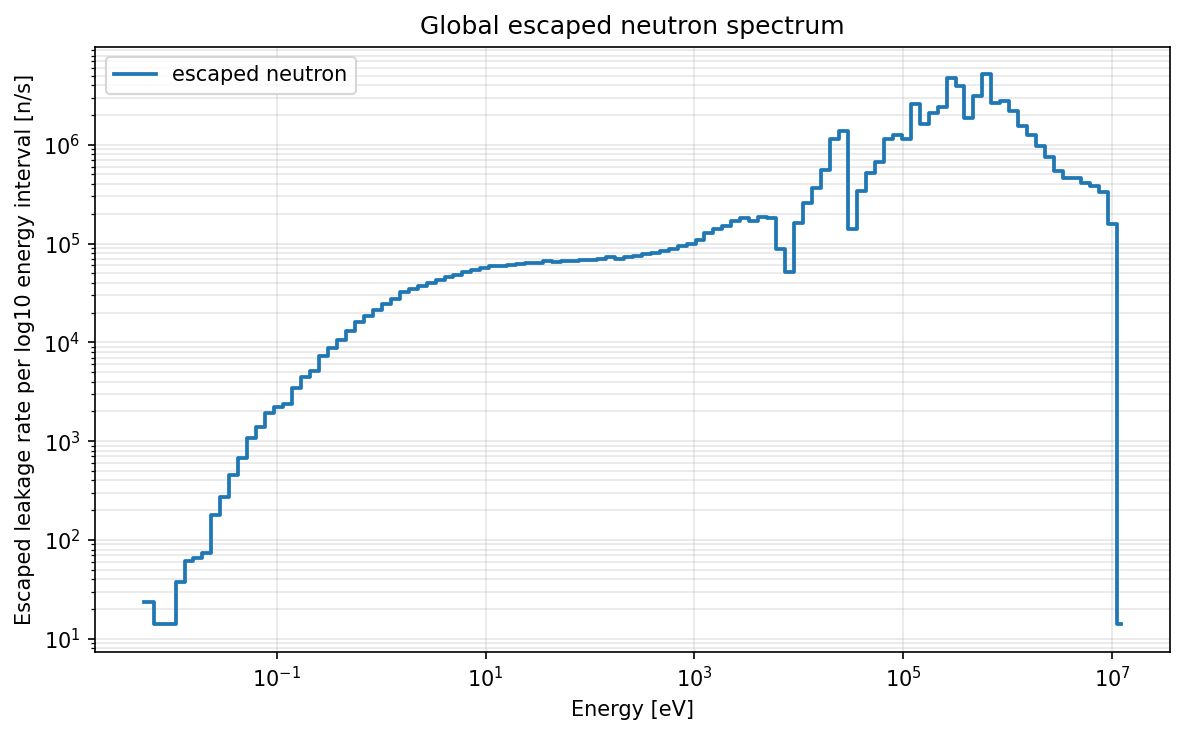

Saved figure: N1_6_energy_resolved_leakage_outputs/figures/global_escaped_neutron_spectrum.png


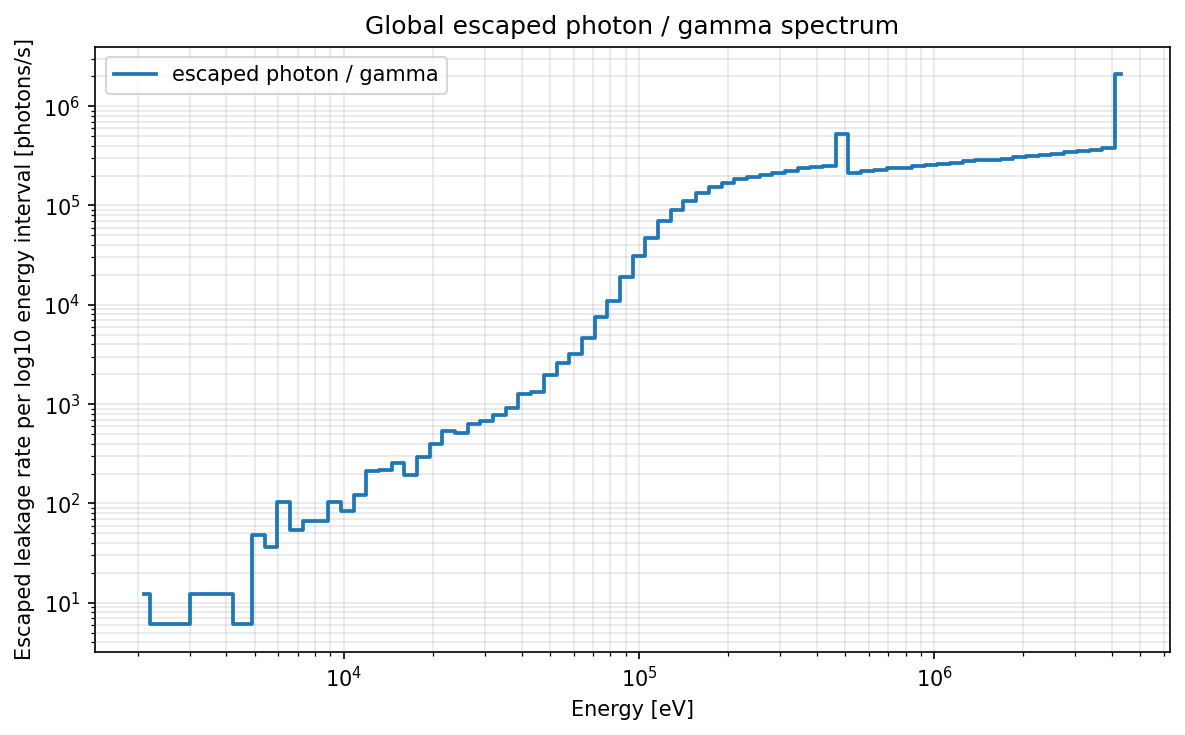

Saved figure: N1_6_energy_resolved_leakage_outputs/figures/global_escaped_photon_spectrum.png


In [20]:
# ============================================================
# 7) Escaped energy spectra
# ============================================================

def particle_label(particle):
    if particle == "photon":
        return "photon / gamma"
    return particle


def leakage_unit_label(particle):
    if particle == "photon":
        return "photons/s"
    return "n/s"


def plot_global_escaped_spectrum(particle):
    """
    Plot globally escaped spectrum summed over all closed-box sides.
    """

    df = global_leakage_spectrum_df[
        global_leakage_spectrum_df["particle"] == particle
    ].copy()

    df = df[df["leakage_rate_per_log10_energy"] > 0.0]

    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

    ax.step(
        df["energy_mid_eV"],
        df["leakage_rate_per_log10_energy"],
        where="mid",
        linewidth=1.8,
        label=f"escaped {particle_label(particle)}",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [eV]")
    ax.set_ylabel(
        f"Escaped leakage rate per log10 energy interval "
        f"[{leakage_unit_label(particle)}]"
    )
    ax.set_title(
        f"Global escaped {particle_label(particle)} spectrum"
    )
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"global_escaped_{particle}_spectrum.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure: {fig_path}")


plot_global_escaped_spectrum("neutron")
plot_global_escaped_spectrum("photon")

## 8) Energy-dependent leakage through each side

The leakage spectra are now separated by box side. This shows whether different parts of the shielding leak different energy components.

For neutrons, the energy groups are classified as:

* thermal: $E < 0.5$ eV,
* epithermal/intermediate: $0.5$ eV $\leq E < 10^5$ eV,
* fast: $E \geq 10^5$ eV.

For photons, the groups are classified as:

* low-energy photons: $E < 0.1$ MeV,
* intermediate photons: $0.1$ MeV $\leq E < 1$ MeV,
* high-energy photons: $E \geq 1$ MeV.


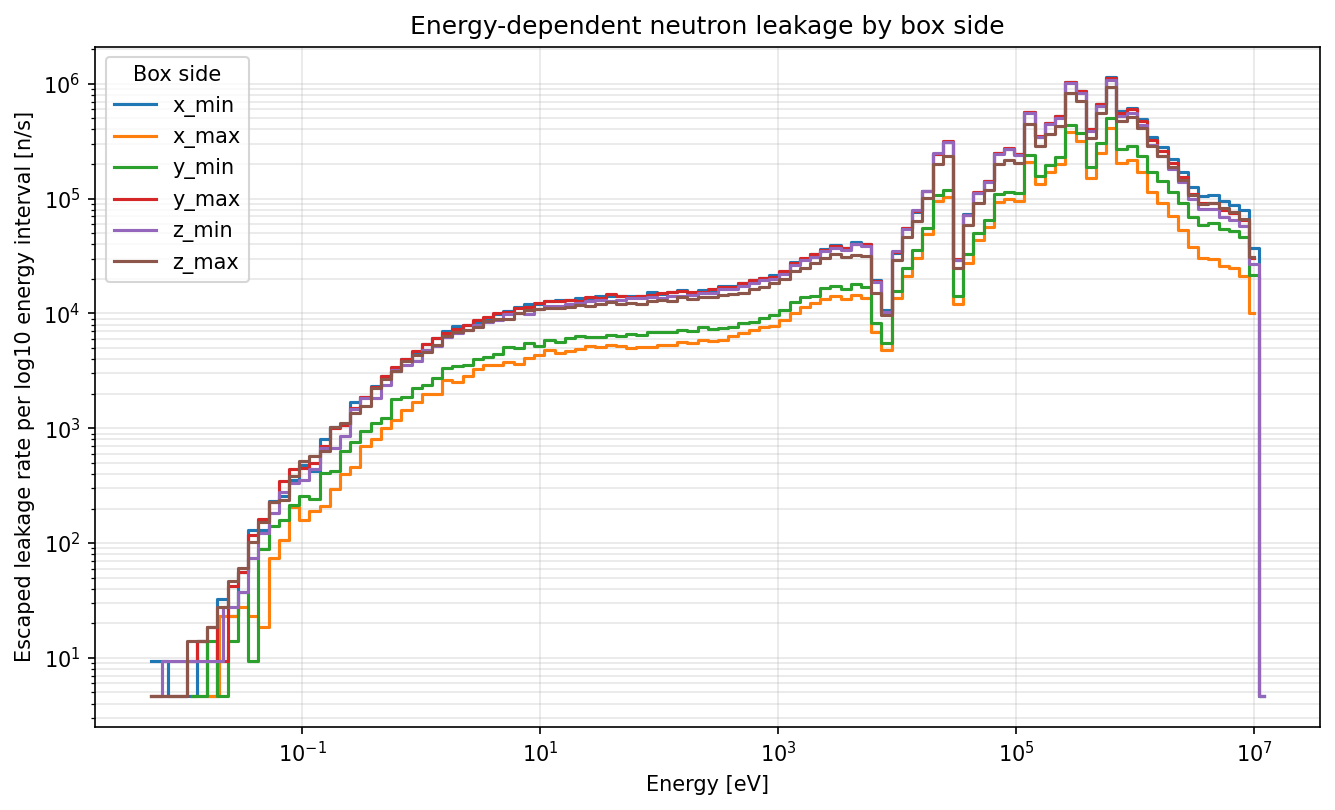

Saved figure: N1_6_energy_resolved_leakage_outputs/figures/neutron_energy_dependent_leakage_by_side.png


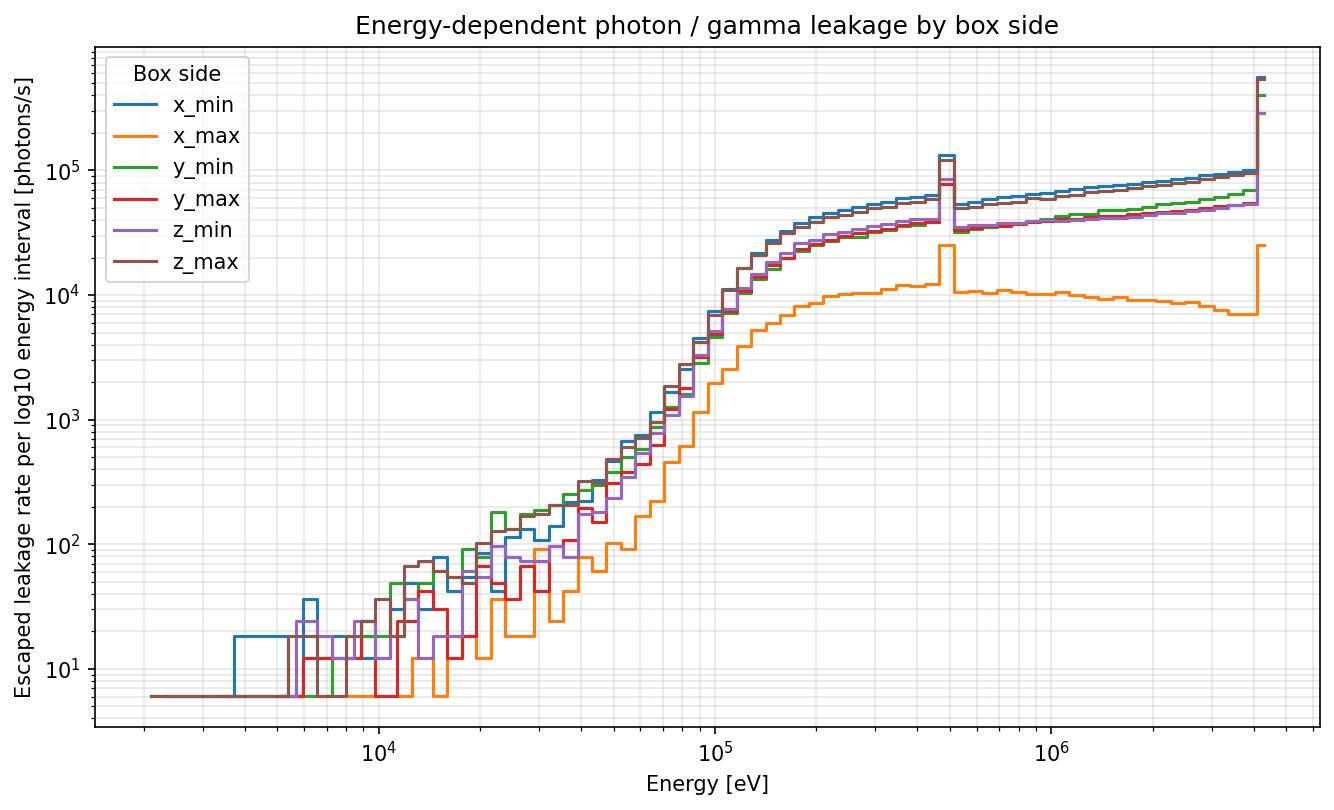

Saved figure: N1_6_energy_resolved_leakage_outputs/figures/photon_energy_dependent_leakage_by_side.png


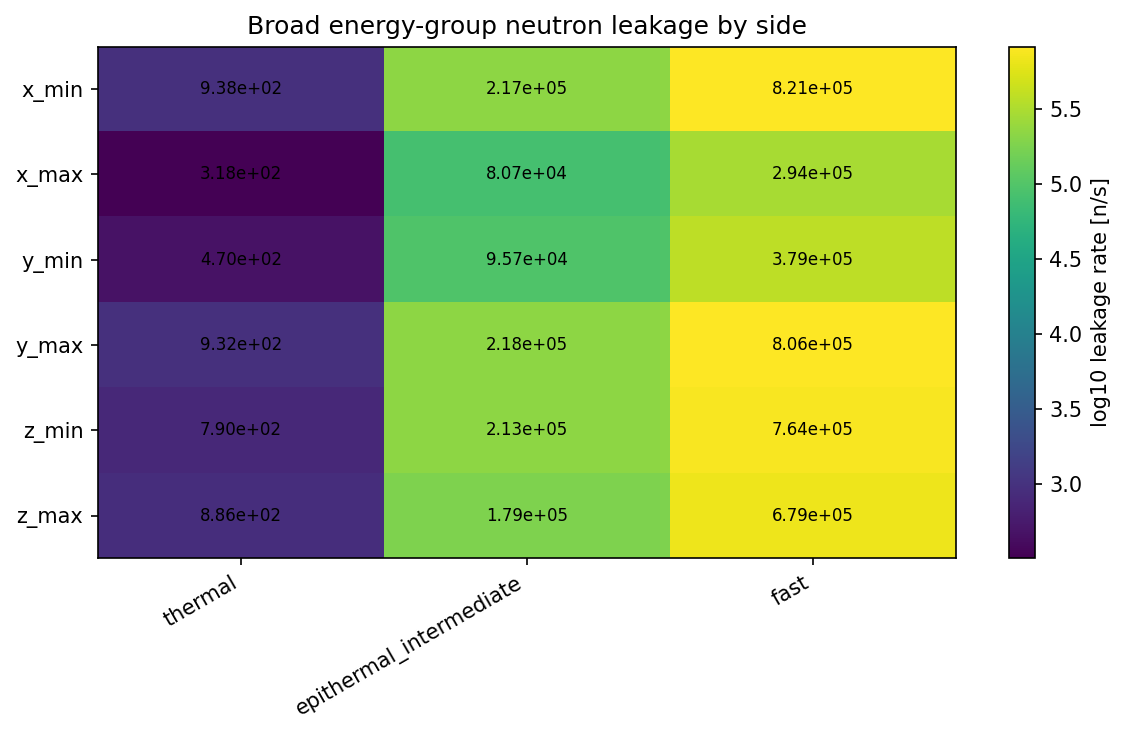

Saved figure: N1_6_energy_resolved_leakage_outputs/figures/neutron_energy_group_leakage_heatmap.png


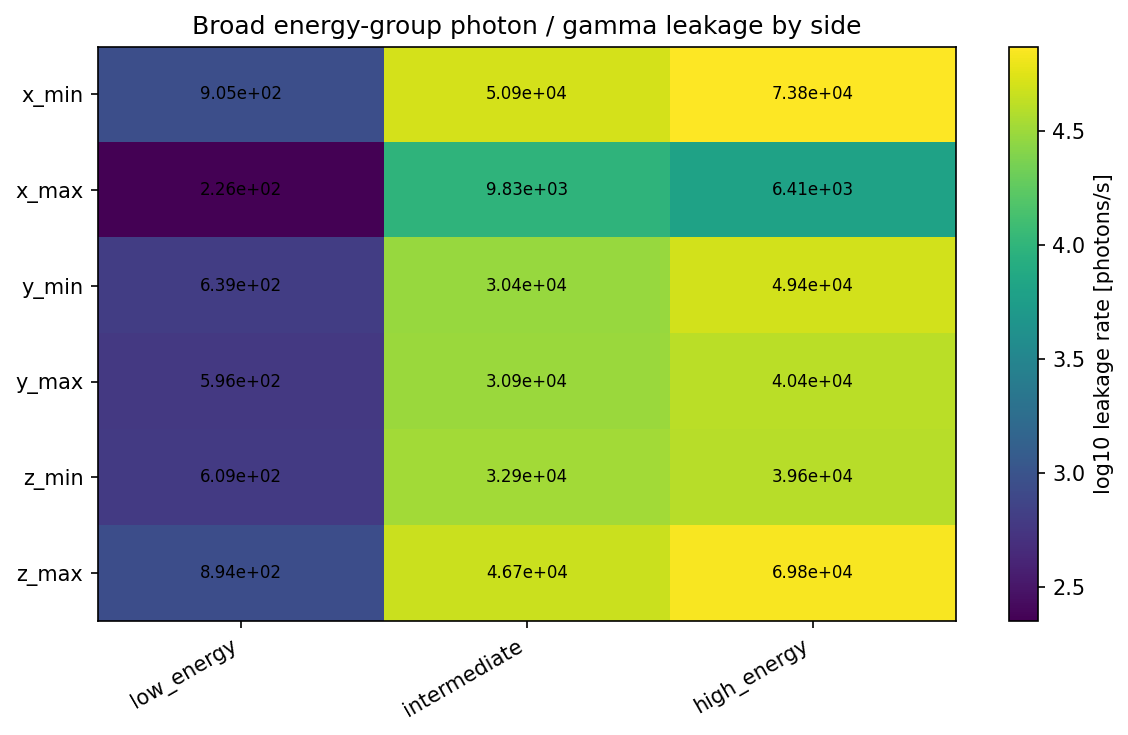

Saved figure: N1_6_energy_resolved_leakage_outputs/figures/photon_energy_group_leakage_heatmap.png

Energy-group leakage summary:


,scenario,particle,side,energy_group,leakage_rate_per_s,leakage_std_per_s,source_strength_per_s,share_of_particle_leakage_percent
0,full_geometry,neutron,x_max,epithermal_intermediate,80736.400000,182.594368,1.200000e+07,1.699212
1,full_geometry,neutron,x_max,fast,294157.999991,346.385506,1.200000e+07,6.190971
2,full_geometry,neutron,x_max,thermal,318.000000,11.436794,1.200000e+07,0.006693
3,full_geometry,neutron,x_min,epithermal_intermediate,217362.799986,312.185759,1.200000e+07,4.574707
4,full_geometry,neutron,x_min,fast,821232.799993,588.588874,1.200000e+07,17.284004
5,full_geometry,neutron,x_min,thermal,937.600000,20.932457,1.200000e+07,0.019733
6,full_geometry,neutron,y_max,epithermal_intermediate,218208.399985,314.751103,1.200000e+07,4.592504
7,full_geometry,neutron,y_max,fast,805521.199969,584.721852,1.200000e+07,16.953331
8,full_geometry,neutron,y_max,thermal,931.600000,21.307382,1.200000e+07,0.019607
9,full_geometry,neutron,y_min,epithermal_intermediate,95660.400000,198.078549,1.200000e+07,2.013308


In [21]:
# ============================================================
# 8) Energy-dependent leakage through each side
# ============================================================

def classify_energy_group(particle, energy_mid_eV):
    """
    Assign broad energy group labels.
    """

    if particle == "neutron":
        if energy_mid_eV < 0.5:
            return "thermal"
        elif energy_mid_eV < 1.0e5:
            return "epithermal_intermediate"
        else:
            return "fast"

    if particle == "photon":
        if energy_mid_eV < 1.0e5:
            return "low_energy"
        elif energy_mid_eV < 1.0e6:
            return "intermediate"
        else:
            return "high_energy"

    return "unknown"


energy_resolved_leakage_df["energy_group"] = energy_resolved_leakage_df.apply(
    lambda row: classify_energy_group(
        row["particle"],
        row["energy_mid_eV"],
    ),
    axis=1,
)


energy_group_side_summary_df = (
    energy_resolved_leakage_df
    .groupby(["scenario", "particle", "side", "energy_group"], as_index=False)
    .agg(
        leakage_rate_per_s=("leakage_rate_per_s", "sum"),
        leakage_std_per_s=("leakage_std_per_s", quadrature_sum),
        source_strength_per_s=("source_strength_per_s", "first"),
    )
)

particle_group_totals = (
    energy_group_side_summary_df
    .groupby(["scenario", "particle"])["leakage_rate_per_s"]
    .transform("sum")
)

energy_group_side_summary_df["share_of_particle_leakage_percent"] = (
    100.0
    * energy_group_side_summary_df["leakage_rate_per_s"]
    / particle_group_totals
)


def plot_side_resolved_spectra(particle):
    """
    Plot escaped spectra for each side of the closed box.
    """

    df = energy_resolved_leakage_df[
        energy_resolved_leakage_df["particle"] == particle
    ].copy()

    fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

    for side_name in SIDE_ORDER:
        sub = df[
            (df["side"] == side_name)
            & (df["leakage_rate_per_log10_energy"] > 0.0)
        ].sort_values("energy_mid_eV")

        if len(sub) == 0:
            continue

        ax.step(
            sub["energy_mid_eV"],
            sub["leakage_rate_per_log10_energy"],
            where="mid",
            linewidth=1.5,
            label=side_name,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [eV]")
    ax.set_ylabel(
        f"Escaped leakage rate per log10 energy interval "
        f"[{leakage_unit_label(particle)}]"
    )
    ax.set_title(
        f"Energy-dependent {particle_label(particle)} leakage by box side"
    )
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(title="Box side")

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"{particle}_energy_dependent_leakage_by_side.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure: {fig_path}")


def plot_energy_group_heatmap(particle):
    """
    Plot broad energy-group leakage by side as a heatmap.
    """

    df = energy_group_side_summary_df[
        energy_group_side_summary_df["particle"] == particle
    ].copy()

    if particle == "neutron":
        group_order = [
            "thermal",
            "epithermal_intermediate",
            "fast",
        ]
    else:
        group_order = [
            "low_energy",
            "intermediate",
            "high_energy",
        ]

    pivot = (
        df.pivot_table(
            index="side",
            columns="energy_group",
            values="leakage_rate_per_s",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reindex(index=SIDE_ORDER, columns=group_order)
    )

    plot_values = np.log10(pivot.replace(0.0, np.nan))

    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

    image = ax.imshow(
        plot_values,
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(group_order)))
    ax.set_xticklabels(group_order, rotation=30, ha="right")
    ax.set_yticks(np.arange(len(SIDE_ORDER)))
    ax.set_yticklabels(SIDE_ORDER)

    ax.set_title(
        f"Broad energy-group {particle_label(particle)} leakage by side"
    )

    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label(
        f"log10 leakage rate [{leakage_unit_label(particle)}]"
    )

    # Add numerical labels
    for i, side_name in enumerate(SIDE_ORDER):
        for j, group_name in enumerate(group_order):
            value = pivot.loc[side_name, group_name]

            if np.isfinite(value) and value > 0.0:
                label = f"{value:.2e}"
            else:
                label = "0"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=8,
            )

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"{particle}_energy_group_leakage_heatmap.png"
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved figure: {fig_path}")


plot_side_resolved_spectra("neutron")
plot_side_resolved_spectra("photon")

plot_energy_group_heatmap("neutron")
plot_energy_group_heatmap("photon")

print()
print("Energy-group leakage summary:")
display(energy_group_side_summary_df)

### 8.5) Smoothed visual representation by logarithmic rebinning

The original energy-resolved leakage tallies are kept as the quantitative result.  
However, the fine energy-bin spectra can be visually noisy because each bin is a separate Monte Carlo tally estimate.

To improve readability without replacing the original data, the plots below show two curves:

- a faint raw curve using the original energy bins,
- a cleaner rebinned curve where neighbouring logarithmic energy bins are combined.

The rebinned curve is only used as a visual guide. Integrated leakage rates, particle balances and energy-group summaries are still based on the original tally data.

Loaded energy-resolved leakage table from: N1_6_energy_resolved_leakage_outputs/tables/energy_resolved_leakage_full.csv
Rows in raw leakage table: 1320

Saved rebinned plotting tables:
  N1_6_energy_resolved_leakage_outputs/tables/global_escaped_energy_spectrum_rebinned_for_plotting.csv
  N1_6_energy_resolved_leakage_outputs/tables/energy_dependent_leakage_by_side_rebinned_for_plotting.csv
Saved figure: N1_6_energy_resolved_leakage_outputs/figures/global_escaped_neutron_spectrum_raw_plus_rebinned.png


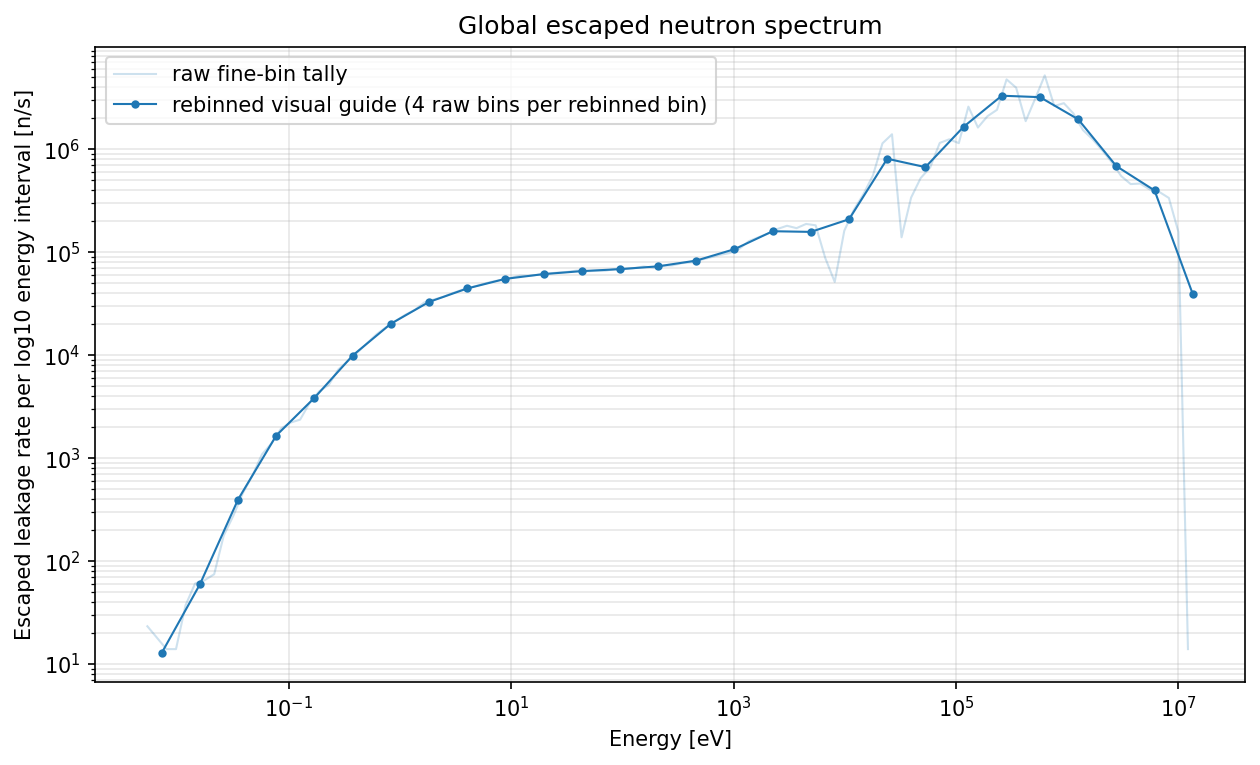

Saved figure: N1_6_energy_resolved_leakage_outputs/figures/global_escaped_photon_spectrum_raw_plus_rebinned.png


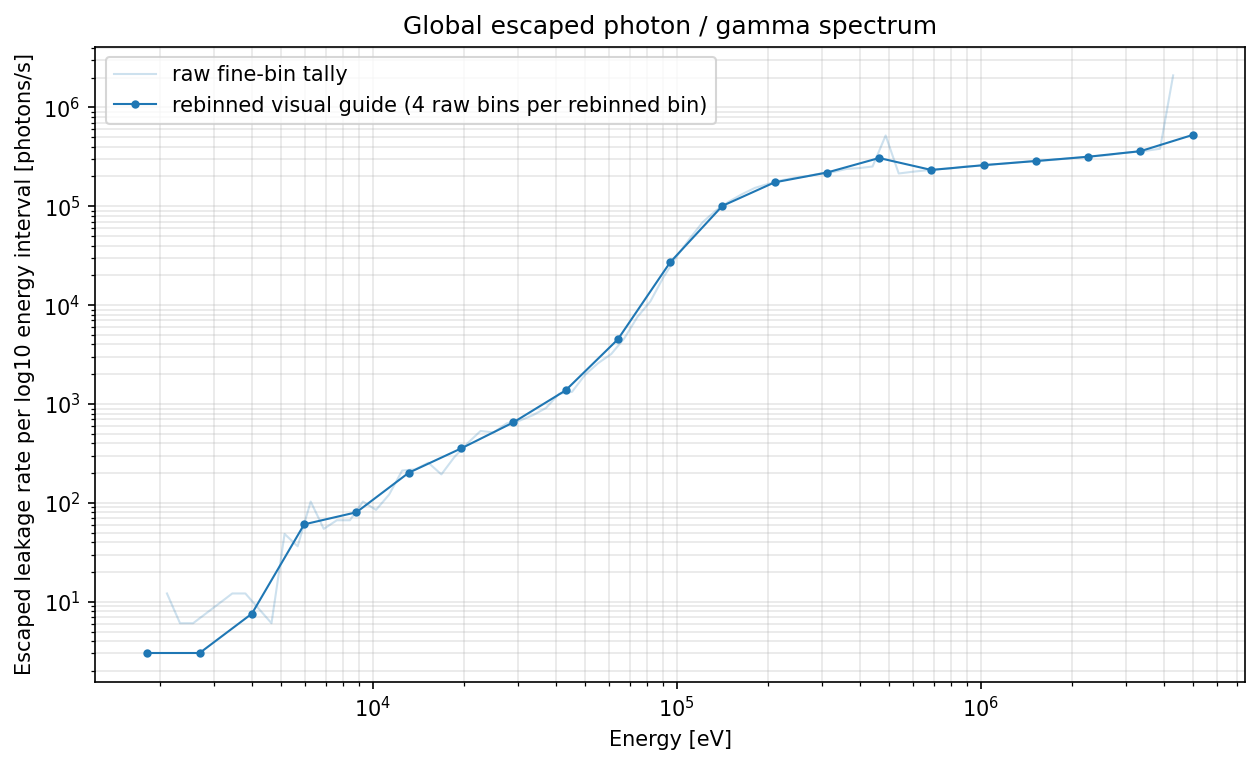

Saved figure: N1_6_energy_resolved_leakage_outputs/figures/energy_dependent_neutron_leakage_by_side_raw_plus_rebinned.png


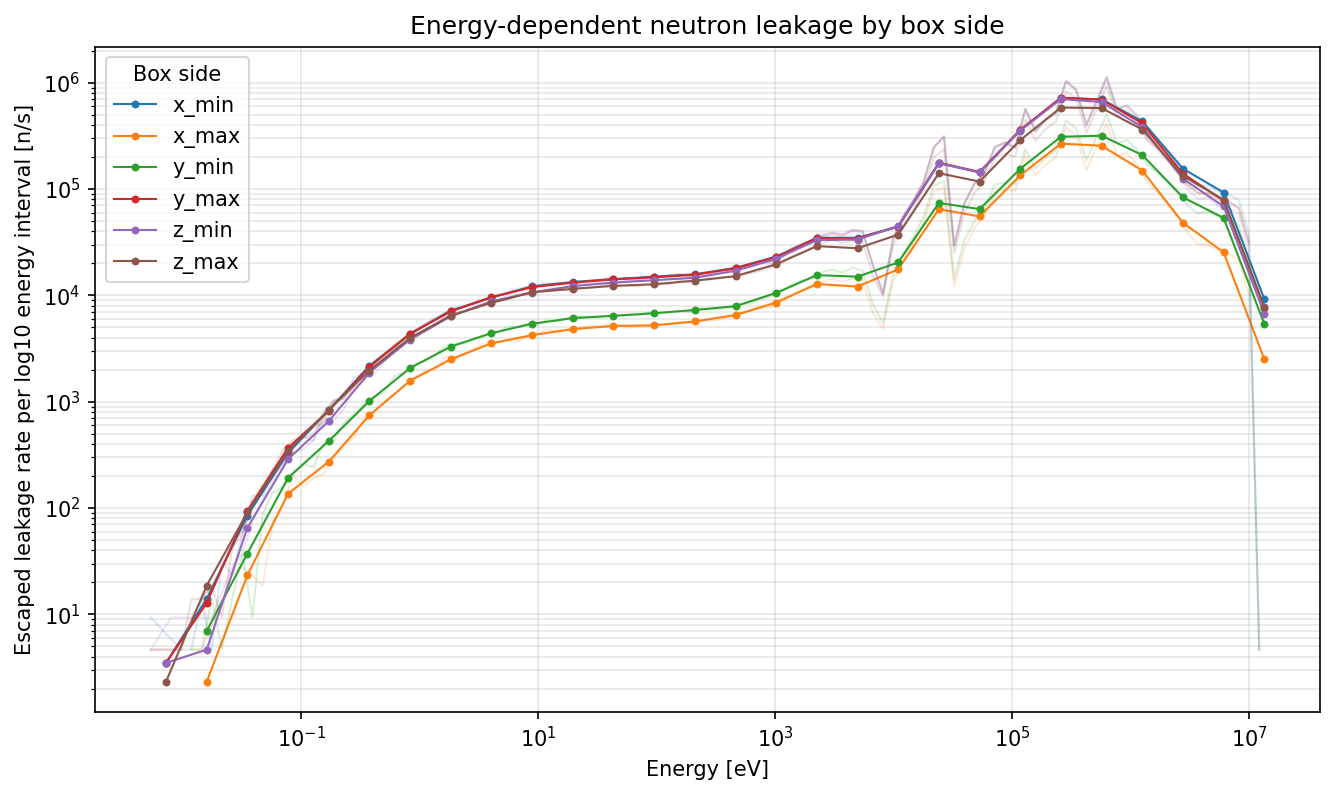

Saved figure: N1_6_energy_resolved_leakage_outputs/figures/energy_dependent_photon_leakage_by_side_raw_plus_rebinned.png


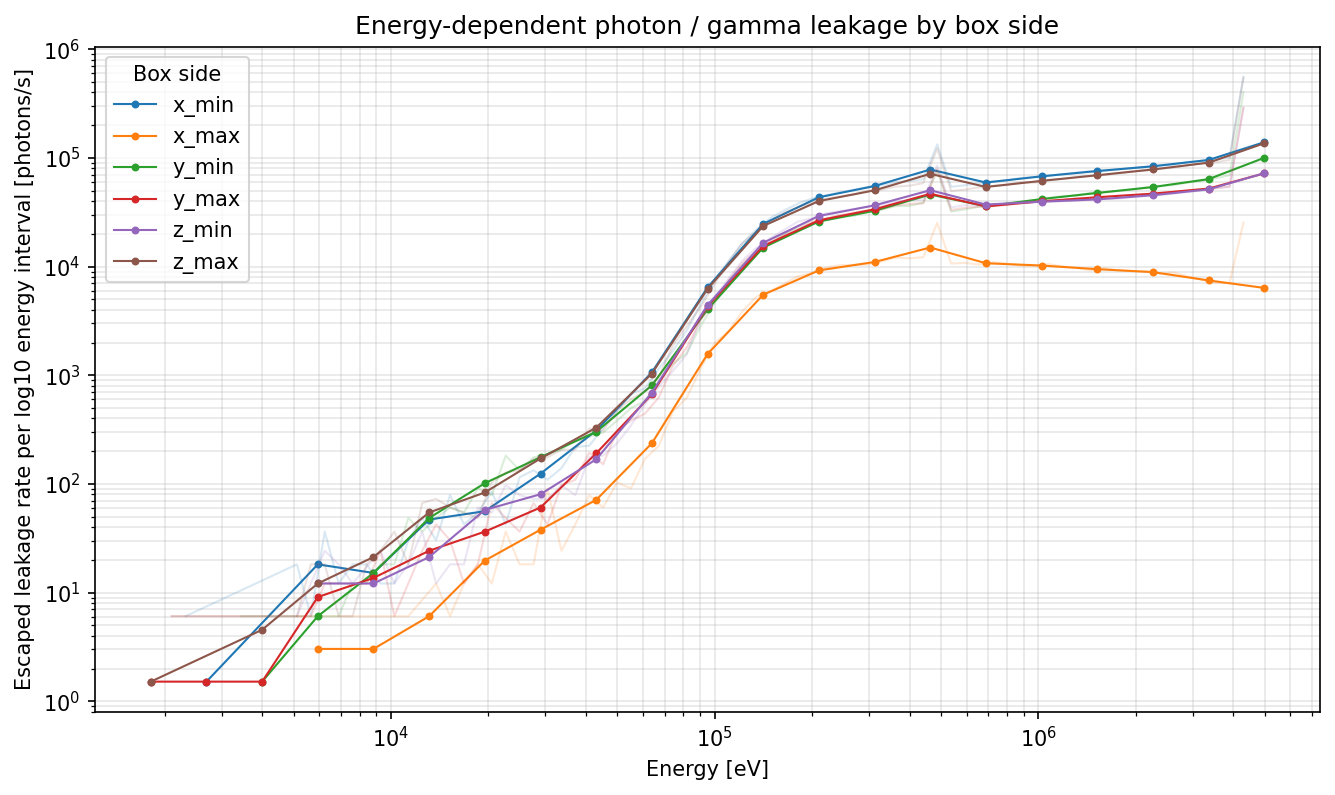


Rebinning summary:
  Raw bins per rebinned plotting bin: 4
  Raw rows:      1320
  Global rows:   55
  Side rows:     330


In [7]:
# ============================================================
# Raw + rebinned energy-resolved leakage plots
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

OUTPUT_DIR = Path("N1_6_energy_resolved_leakage_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Find the main energy-resolved leakage table
# ------------------------------------------------------------

candidate_names = [
    "energy_resolved_leakage_df",
    "energy_resolved_df",
    "leakage_energy_df",
]

leakage_df = None

for name in candidate_names:
    if name in globals():
        leakage_df = globals()[name].copy()
        print(f"Using energy-resolved leakage table from variable: {name}")
        break

if leakage_df is None:
    possible_files = list(TABLE_DIR.glob("*energy*resolved*leakage*.csv"))
    if len(possible_files) == 0:
        raise FileNotFoundError(
            "Could not find an energy-resolved leakage table in memory or in the output folder."
        )

    leakage_df = pd.read_csv(possible_files[0])
    print(f"Loaded energy-resolved leakage table from: {possible_files[0]}")

print(f"Rows in raw leakage table: {len(leakage_df)}")


# ------------------------------------------------------------
# Make sure required columns exist
# ------------------------------------------------------------

required_columns = [
    "scenario",
    "particle",
    "side",
    "energy_low_eV",
    "energy_high_eV",
    "energy_mid_eV",
    "leakage_rate_per_s",
]

missing_columns = [col for col in required_columns if col not in leakage_df.columns]

if missing_columns:
    raise KeyError(
        "The energy-resolved leakage table is missing these required columns:\n"
        f"{missing_columns}"
    )

if "leakage_std_per_s" not in leakage_df.columns:
    leakage_df["leakage_std_per_s"] = 0.0

if "dlog10_energy" not in leakage_df.columns:
    leakage_df["dlog10_energy"] = np.log10(
        leakage_df["energy_high_eV"] / leakage_df["energy_low_eV"]
    )

if "leakage_rate_per_log10_energy" not in leakage_df.columns:
    leakage_df["leakage_rate_per_log10_energy"] = (
        leakage_df["leakage_rate_per_s"] / leakage_df["dlog10_energy"]
    )

if "leakage_std_per_log10_energy" not in leakage_df.columns:
    leakage_df["leakage_std_per_log10_energy"] = (
        leakage_df["leakage_std_per_s"] / leakage_df["dlog10_energy"]
    )


# ------------------------------------------------------------
# Rebin neighbouring logarithmic energy bins
# ------------------------------------------------------------

RAW_BINS_PER_REBIN = 4
# Increase to 5 or 6 for a smoother curve.
# Decrease to 2 or 3 if you want to preserve more detail.


def rebin_adjacent_energy_bins(
    df,
    group_columns,
    raw_bins_per_rebin=RAW_BINS_PER_REBIN,
):
    """
    Combine neighbouring energy bins inside each group.

    This is not a mathematical smoothing filter.
    It is a conservative rebinning of the original tally bins.
    """

    rebinned_groups = []

    for group_values, sub in df.groupby(group_columns, dropna=False):
        sub = sub.sort_values("energy_low_eV").reset_index(drop=True).copy()

        sub["rebin_index"] = np.arange(len(sub)) // raw_bins_per_rebin

        grouped = sub.groupby("rebin_index", dropna=False)

        rebinned = grouped.agg(
            energy_low_eV=("energy_low_eV", "min"),
            energy_high_eV=("energy_high_eV", "max"),
            leakage_rate_per_s=("leakage_rate_per_s", "sum"),
            leakage_std_per_s=("leakage_std_per_s", lambda x: np.sqrt(np.sum(np.asarray(x) ** 2))),
        ).reset_index(drop=True)

        rebinned["energy_mid_eV"] = np.sqrt(
            rebinned["energy_low_eV"] * rebinned["energy_high_eV"]
        )

        rebinned["energy_width_eV"] = (
            rebinned["energy_high_eV"] - rebinned["energy_low_eV"]
        )

        rebinned["dlog10_energy"] = np.log10(
            rebinned["energy_high_eV"] / rebinned["energy_low_eV"]
        )

        rebinned["leakage_rate_per_log10_energy"] = (
            rebinned["leakage_rate_per_s"] / rebinned["dlog10_energy"]
        )

        rebinned["leakage_std_per_log10_energy"] = (
            rebinned["leakage_std_per_s"] / rebinned["dlog10_energy"]
        )

        rebinned["relative_uncertainty_percent"] = np.where(
            rebinned["leakage_rate_per_s"] > 0,
            100.0 * rebinned["leakage_std_per_s"] / rebinned["leakage_rate_per_s"],
            np.nan,
        )

        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        for col, value in zip(group_columns, group_values):
            rebinned[col] = value

        rebinned_groups.append(rebinned)

    result = pd.concat(rebinned_groups, ignore_index=True)

    ordered_columns = (
        list(group_columns)
        + [
            "energy_low_eV",
            "energy_high_eV",
            "energy_mid_eV",
            "energy_width_eV",
            "dlog10_energy",
            "leakage_rate_per_s",
            "leakage_std_per_s",
            "leakage_rate_per_log10_energy",
            "leakage_std_per_log10_energy",
            "relative_uncertainty_percent",
        ]
    )

    return result[ordered_columns]


# ------------------------------------------------------------
# Create global raw spectrum by summing over all six sides
# ------------------------------------------------------------

global_raw_spectrum_df = (
    leakage_df
    .groupby(
        [
            "scenario",
            "particle",
            "energy_low_eV",
            "energy_high_eV",
            "energy_mid_eV",
            "dlog10_energy",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        leakage_rate_per_s=("leakage_rate_per_s", "sum"),
        leakage_std_per_s=("leakage_std_per_s", lambda x: np.sqrt(np.sum(np.asarray(x) ** 2))),
    )
)

global_raw_spectrum_df["leakage_rate_per_log10_energy"] = (
    global_raw_spectrum_df["leakage_rate_per_s"]
    / global_raw_spectrum_df["dlog10_energy"]
)

global_raw_spectrum_df["leakage_std_per_log10_energy"] = (
    global_raw_spectrum_df["leakage_std_per_s"]
    / global_raw_spectrum_df["dlog10_energy"]
)

global_raw_spectrum_df["relative_uncertainty_percent"] = np.where(
    global_raw_spectrum_df["leakage_rate_per_s"] > 0,
    100.0
    * global_raw_spectrum_df["leakage_std_per_s"]
    / global_raw_spectrum_df["leakage_rate_per_s"],
    np.nan,
)


# ------------------------------------------------------------
# Create rebinned tables
# ------------------------------------------------------------

global_rebinned_spectrum_df = rebin_adjacent_energy_bins(
    global_raw_spectrum_df,
    group_columns=["scenario", "particle"],
    raw_bins_per_rebin=RAW_BINS_PER_REBIN,
)

side_rebinned_spectrum_df = rebin_adjacent_energy_bins(
    leakage_df,
    group_columns=["scenario", "particle", "side"],
    raw_bins_per_rebin=RAW_BINS_PER_REBIN,
)


# ------------------------------------------------------------
# Save rebinned plotting tables
# ------------------------------------------------------------

global_rebinned_path = TABLE_DIR / "global_escaped_energy_spectrum_rebinned_for_plotting.csv"
side_rebinned_path = TABLE_DIR / "energy_dependent_leakage_by_side_rebinned_for_plotting.csv"

global_rebinned_spectrum_df.to_csv(global_rebinned_path, index=False)
side_rebinned_spectrum_df.to_csv(side_rebinned_path, index=False)

print()
print("Saved rebinned plotting tables:")
print(f"  {global_rebinned_path}")
print(f"  {side_rebinned_path}")


# ------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------

def particle_label(particle):
    if particle == "neutron":
        return "neutron"
    if particle == "photon":
        return "photon / gamma"
    return str(particle)


def particle_rate_unit(particle):
    if particle == "neutron":
        return "n/s"
    if particle == "photon":
        return "photons/s"
    return "particles/s"


def plot_global_raw_and_rebinned_spectrum(particle):
    """
    Plot global escaped spectrum:
    faint raw fine-bin curve + clean rebinned curve.
    """

    raw = global_raw_spectrum_df[
        (global_raw_spectrum_df["particle"] == particle)
        & (global_raw_spectrum_df["leakage_rate_per_log10_energy"] > 0)
    ].sort_values("energy_mid_eV")

    rebinned = global_rebinned_spectrum_df[
        (global_rebinned_spectrum_df["particle"] == particle)
        & (global_rebinned_spectrum_df["leakage_rate_per_log10_energy"] > 0)
    ].sort_values("energy_mid_eV")

    if raw.empty or rebinned.empty:
        print(f"No positive spectrum data available for particle = {particle}")
        return None

    fig, ax = plt.subplots(figsize=(8.5, 5.2), dpi=150)

    raw_line, = ax.plot(
        raw["energy_mid_eV"],
        raw["leakage_rate_per_log10_energy"],
        linewidth=1.0,
        alpha=0.22,
        label="raw fine-bin tally",
    )

    ax.plot(
        rebinned["energy_mid_eV"],
        rebinned["leakage_rate_per_log10_energy"],
        linewidth=1.0,
        marker="o",
        markersize=3.0,
        color=raw_line.get_color(),
        label=f"rebinned visual guide ({RAW_BINS_PER_REBIN} raw bins per rebinned bin)",
    )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Energy [eV]")
    ax.set_ylabel(
        f"Escaped leakage rate per log10 energy interval [{particle_rate_unit(particle)}]"
    )

    ax.set_title(f"Global escaped {particle_label(particle)} spectrum")
    ax.grid(True, which="both", alpha=0.30)
    ax.legend()

    fig.tight_layout()

    filename = (
        FIGURE_DIR
        / f"global_escaped_{particle}_spectrum_raw_plus_rebinned.png"
    )

    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {filename}")

    plt.show()

    return fig


def plot_side_raw_and_rebinned_spectrum(particle):
    """
    Plot energy-dependent leakage through each box side:
    faint raw curves + clean rebinned curves.
    """

    raw_particle = leakage_df[
        (leakage_df["particle"] == particle)
        & (leakage_df["leakage_rate_per_log10_energy"] > 0)
    ].copy()

    rebinned_particle = side_rebinned_spectrum_df[
        (side_rebinned_spectrum_df["particle"] == particle)
        & (side_rebinned_spectrum_df["leakage_rate_per_log10_energy"] > 0)
    ].copy()

    if raw_particle.empty or rebinned_particle.empty:
        print(f"No positive side spectrum data available for particle = {particle}")
        return None

    side_order = ["x_min", "x_max", "y_min", "y_max", "z_min", "z_max"]

    fig, ax = plt.subplots(figsize=(9.0, 5.4), dpi=150)

    for side in side_order:
        raw = raw_particle[
            raw_particle["side"] == side
        ].sort_values("energy_mid_eV")

        rebinned = rebinned_particle[
            rebinned_particle["side"] == side
        ].sort_values("energy_mid_eV")

        if raw.empty or rebinned.empty:
            continue

        raw_line, = ax.plot(
            raw["energy_mid_eV"],
            raw["leakage_rate_per_log10_energy"],
            linewidth=1.0,
            alpha=0.17,
            label="_nolegend_",
        )

        ax.plot(
            rebinned["energy_mid_eV"],
            rebinned["leakage_rate_per_log10_energy"],
            linewidth=1.0,
            marker="o",
            markersize=2.8,
            color=raw_line.get_color(),
            label=side,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Energy [eV]")
    ax.set_ylabel(
        f"Escaped leakage rate per log10 energy interval [{particle_rate_unit(particle)}]"
    )

    ax.set_title(
        f"Energy-dependent {particle_label(particle)} leakage by box side"
    )

    ax.grid(True, which="both", alpha=0.30)
    ax.legend(title="Box side")

    fig.tight_layout()

    filename = (
        FIGURE_DIR
        / f"energy_dependent_{particle}_leakage_by_side_raw_plus_rebinned.png"
    )

    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {filename}")

    plt.show()

    return fig


# ------------------------------------------------------------
# Make plots
# ------------------------------------------------------------

fig_global_neutron_rebinned = plot_global_raw_and_rebinned_spectrum("neutron")
fig_global_photon_rebinned = plot_global_raw_and_rebinned_spectrum("photon")

fig_side_neutron_rebinned = plot_side_raw_and_rebinned_spectrum("neutron")
fig_side_photon_rebinned = plot_side_raw_and_rebinned_spectrum("photon")


# ------------------------------------------------------------
# Display quick summary
# ------------------------------------------------------------

print()
print("Rebinning summary:")
print(f"  Raw bins per rebinned plotting bin: {RAW_BINS_PER_REBIN}")
print(f"  Raw rows:      {len(leakage_df)}")
print(f"  Global rows:   {len(global_rebinned_spectrum_df)}")
print(f"  Side rows:     {len(side_rebinned_spectrum_df)}")

## 9) Save final outputs

The final tables, figures and metadata from the energy-resolved leakage analysis are saved in the output folder.

The most important output tables are:

* the full energy-resolved leakage table,
* the side-integrated leakage summary,
* the global escaped energy spectrum,
* the global neutron/photon balance,
* the broad energy-group leakage summary.


In [22]:
# ============================================================
# 9) Save final outputs
# ============================================================

export_log = []


def save_df(df, filename, description):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)

    export_log.append({
        "filename": str(path),
        "description": description,
        "rows": len(df),
        "columns": len(df.columns),
        "status": "saved",
    })

    return path


save_df(
    energy_resolved_leakage_df,
    "energy_resolved_leakage_full.csv",
    "Full energy-resolved leakage table by particle, side and energy bin.",
)

save_df(
    side_leakage_summary_df,
    "side_integrated_leakage_summary.csv",
    "Energy-integrated leakage summary by particle and box side.",
)

save_df(
    global_leakage_spectrum_df,
    "global_escaped_energy_spectrum.csv",
    "Escaped energy spectra summed over all box sides.",
)

save_df(
    global_balance_summary_df,
    "global_neutron_photon_balance.csv",
    "Global escaped particle balance for neutron and photon simulations.",
)

save_df(
    energy_group_side_summary_df,
    "energy_group_leakage_by_side.csv",
    "Broad energy-group leakage summary by particle and box side.",
)


# ------------------------------------------------------------
# Main final summary table in project root
# ------------------------------------------------------------

root_balance_path = Path("energy_resolved_global_leakage_balance_final.csv")
global_balance_summary_df.to_csv(root_balance_path, index=False)

export_log.append({
    "filename": str(root_balance_path),
    "description": "Root-level final global leakage balance table.",
    "rows": len(global_balance_summary_df),
    "columns": len(global_balance_summary_df.columns),
    "status": "saved",
})


# ------------------------------------------------------------
# Metadata
# ------------------------------------------------------------

metadata = {
    "notebook": "1_6_AmBe_Paraffin_Energy_resolved_leakage.ipynb",
    "created": datetime.now().isoformat(timespec="seconds"),
    "purpose": (
        "Energy-resolved closed-box leakage and global particle-balance "
        "analysis for the Am-Be/paraffin/cabinet model."
    ),
    "output_folder": str(OUTPUT_DIR),
    "table_folder": str(TABLE_DIR),
    "figure_folder": str(FIGURE_DIR),
    "metadata_folder": str(METADATA_DIR),
    "run_settings": {
        "batches": RUN_BATCHES,
        "particles": RUN_PARTICLES,
        "histories": RUN_BATCHES * RUN_PARTICLES,
    },
    "source_strengths": {
        "neutron_source_strength_per_s": SOURCE_NEUTRON_EMISSION,
        "gamma_source_strength_per_s": GAMMA_SOURCE_EMISSION,
        "gamma_per_neutron_source_ratio": GAMMA_PER_NEUTRON_RATIO,
    },
    "energy_bins": {
        "neutron_min_eV": float(NEUTRON_ENERGY_BINS_EV[0]),
        "neutron_max_eV": float(NEUTRON_ENERGY_BINS_EV[-1]),
        "neutron_number_of_bins": int(len(NEUTRON_ENERGY_BINS_EV) - 1),
        "photon_min_eV": float(PHOTON_ENERGY_BINS_EV[0]),
        "photon_max_eV": float(PHOTON_ENERGY_BINS_EV[-1]),
        "photon_number_of_bins": int(len(PHOTON_ENERGY_BINS_EV) - 1),
    },
    "side_order": SIDE_ORDER,
    "interpretation_note": (
        "The closed-box leakage tally gives a global leakage estimate. "
        "It is complementary to local detector-point dose-rate tallies."
    ),
}

metadata_path = METADATA_DIR / "energy_resolved_leakage_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

export_log.append({
    "filename": str(metadata_path),
    "description": "Metadata for the energy-resolved leakage notebook.",
    "rows": np.nan,
    "columns": np.nan,
    "status": "saved",
})


# ------------------------------------------------------------
# Export log
# ------------------------------------------------------------

export_log_df = pd.DataFrame(export_log)
export_log_path = OUTPUT_DIR / "export_log.csv"
export_log_df.to_csv(export_log_path, index=False)


print("Notebook 1.6 outputs saved.")
print()
print("Output folder:")
print(f"  {OUTPUT_DIR}/")
print()
print("Tables:")
print(f"  {TABLE_DIR}/")
print()
print("Figures:")
print(f"  {FIGURE_DIR}/")
print()
print("Metadata:")
print(f"  {metadata_path}")
print()
print("Root final table:")
print(f"  {root_balance_path}")

print()
print("Export log:")
display(export_log_df)

Notebook 1.6 outputs saved.

Output folder:
  N1_6_energy_resolved_leakage_outputs/

Tables:
  N1_6_energy_resolved_leakage_outputs/tables/

Figures:
  N1_6_energy_resolved_leakage_outputs/figures/

Metadata:
  N1_6_energy_resolved_leakage_outputs/metadata/energy_resolved_leakage_metadata.json

Root final table:
  energy_resolved_global_leakage_balance_final.csv

Export log:


,filename,description,rows,columns,status
0,N1_6_energy_resolved_leakage_outputs/tables/en...,Full energy-resolved leakage table by particle...,1320.0,20.0,saved
1,N1_6_energy_resolved_leakage_outputs/tables/si...,Energy-integrated leakage summary by particle ...,12.0,8.0,saved
2,N1_6_energy_resolved_leakage_outputs/tables/gl...,Escaped energy spectra summed over all box sides.,220.0,13.0,saved
3,N1_6_energy_resolved_leakage_outputs/tables/gl...,Global escaped particle balance for neutron an...,2.0,9.0,saved
4,N1_6_energy_resolved_leakage_outputs/tables/en...,Broad energy-group leakage summary by particle...,36.0,8.0,saved
5,energy_resolved_global_leakage_balance_final.csv,Root-level final global leakage balance table.,2.0,9.0,saved
6,N1_6_energy_resolved_leakage_outputs/metadata/...,Metadata for the energy-resolved leakage noteb...,NaN,NaN,saved


## 10) Consistency check with the closed-box leakage notebook

This section compares the energy-integrated leakage results from the present energy-resolved leakage calculation with the closed-box surface-current leakage results from Notebook 1.5.

The purpose is to verify that the energy-resolved calculation is consistent with the earlier global leakage calculation. The present notebook contains more information because the leakage is resolved by energy, but after summing over all energy bins and all six box sides, the total escaped neutron and photon rates should agree with the previous closed-box current tally within small numerical differences.

This check is therefore used as a consistency test between:

- Notebook 1.5: total closed-box surface-current leakage,
- Notebook 1.6: energy-resolved closed-box surface-current leakage.

In [9]:
# ============================================================
# 10) Consistency check with Notebook 1.5 closed-box leakage
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 10.1) Locate Notebook 1.6 global leakage balance
# ------------------------------------------------------------

n16_candidate_paths = [
    TABLE_DIR / "global_neutron_photon_balance.csv",
    TABLE_DIR / "global_leakage_balance.csv",
    OUTPUT_DIR / "tables" / "global_neutron_photon_balance.csv",
    OUTPUT_DIR / "tables" / "global_leakage_balance.csv",
    Path("N1_6_energy_resolved_leakage_outputs/tables/global_neutron_photon_balance.csv"),
    Path("N1_6_energy_resolved_leakage_outputs/tables/global_leakage_balance.csv"),
    Path("energy_resolved_global_leakage_balance_final.csv"),
]

n16_path = None

for path in n16_candidate_paths:
    if path.exists():
        n16_path = path
        break

if n16_path is None:
    raise FileNotFoundError(
        "Could not find the Notebook 1.6 global leakage balance table. "
        "Run the save-output cell in Notebook 1.6 first."
    )

n16_raw_df = pd.read_csv(n16_path)

print("Found Notebook 1.6 global leakage table:")
print(f"  {n16_path}")


# ------------------------------------------------------------
# 10.2) Standardize Notebook 1.6 columns
# ------------------------------------------------------------

n16_df = n16_raw_df.copy()

n16_rename_map = {
    "escaped_rate_per_s": "n16_leakage_rate_per_s",
    "escaped_std_per_s": "n16_leakage_std_per_s",
    "escaped_fraction": "n16_escaped_fraction",
    "escaped_percent": "n16_escaped_percent",
    "source_strength_per_s": "n16_source_strength_per_s",
    "total_leakage_rate_per_s": "n16_leakage_rate_per_s",
    "total_leakage_std_per_s": "n16_leakage_std_per_s",
    "leakage_rate_per_s": "n16_leakage_rate_per_s",
    "leakage_std_per_s": "n16_leakage_std_per_s",
}

n16_df = n16_df.rename(
    columns={
        old: new
        for old, new in n16_rename_map.items()
        if old in n16_df.columns
    }
)

required_n16_cols = ["particle", "n16_leakage_rate_per_s"]

missing_n16_cols = [
    col for col in required_n16_cols
    if col not in n16_df.columns
]

if missing_n16_cols:
    raise KeyError(
        "Notebook 1.6 global table is missing required columns: "
        f"{missing_n16_cols}. Available columns are: {list(n16_df.columns)}"
    )

if "scenario" not in n16_df.columns:
    n16_df["scenario"] = "full_geometry"

n16_keep_cols = [
    col for col in [
        "scenario",
        "particle",
        "n16_source_strength_per_s",
        "n16_leakage_rate_per_s",
        "n16_leakage_std_per_s",
        "n16_escaped_fraction",
        "n16_escaped_percent",
    ]
    if col in n16_df.columns
]

n16_df = n16_df[n16_keep_cols].copy()


# ------------------------------------------------------------
# 10.3) Locate Notebook 1.5 closed-box leakage table
# ------------------------------------------------------------

n15_candidate_paths = [
    Path("surface_current_leakage_outputs/tables/neutron_photon_shielding_summary.csv"),
    Path("surface_current_leakage_outputs/tables/total_leakage_results.csv"),
    Path("surface_current_leakage_outputs/tables/scenario_effect_summary.csv"),
    Path("closed_box_surface_current_leakage_summary.csv"),
]

n15_path = None

for path in n15_candidate_paths:
    if path.exists():
        n15_path = path
        break

if n15_path is None:
    raise FileNotFoundError(
        "Could not find a Notebook 1.5 closed-box leakage table."
    )

n15_raw_df = pd.read_csv(n15_path)

print()
print("Found Notebook 1.5 comparison table:")
print(f"  {n15_path}")


# ------------------------------------------------------------
# 10.4) Standardize Notebook 1.5 columns
# ------------------------------------------------------------

n15_df = n15_raw_df.copy()

print()
print("Notebook 1.5 columns:")
print(list(n15_df.columns))


# Case A:
# neutron_photon_shielding_summary.csv
# contains full_geometry_leakage_rate directly.
if "full_geometry_leakage_rate" in n15_df.columns:
    n15_df = n15_df.rename(
        columns={
            "full_geometry_leakage_rate": "n15_leakage_rate_per_s",
            "unit": "n15_unit",
        }
    )

    if "scenario" not in n15_df.columns:
        n15_df["scenario"] = "full_geometry"

    n15_df = n15_df[
        [
            "scenario",
            "particle",
            "n15_leakage_rate_per_s",
            "n15_unit",
        ]
    ].copy()


# Case B:
# total_leakage_results.csv
# contains one row per scenario and particle.
elif "total_leakage_rate" in n15_df.columns:
    n15_df = n15_df.rename(
        columns={
            "total_leakage_rate": "n15_leakage_rate_per_s",
            "total_leakage_rate_std": "n15_leakage_std_per_s",
            "leakage_rate_unit": "n15_unit",
        }
    )

    if "scenario" in n15_df.columns:
        n15_df = n15_df[n15_df["scenario"] == "full_geometry"].copy()
    else:
        n15_df["scenario"] = "full_geometry"

    keep_cols = [
        col for col in [
            "scenario",
            "particle",
            "n15_leakage_rate_per_s",
            "n15_leakage_std_per_s",
            "n15_unit",
        ]
        if col in n15_df.columns
    ]

    n15_df = n15_df[keep_cols].copy()


# Case C:
# scenario_effect_summary.csv / closed_box_surface_current_leakage_summary.csv
# contains full_total_leakage_rate.
elif "full_total_leakage_rate" in n15_df.columns:
    n15_df = n15_df.rename(
        columns={
            "full_total_leakage_rate": "n15_leakage_rate_per_s",
            "leakage_rate_unit": "n15_unit",
        }
    )

    if "scenario" not in n15_df.columns:
        n15_df["scenario"] = "full_geometry"

    keep_cols = [
        col for col in [
            "scenario",
            "particle",
            "n15_leakage_rate_per_s",
            "n15_unit",
        ]
        if col in n15_df.columns
    ]

    n15_df = n15_df[keep_cols].copy()


else:
    raise KeyError(
        "Could not identify the Notebook 1.5 leakage-rate column. "
        f"Available columns are: {list(n15_df.columns)}"
    )


# ------------------------------------------------------------
# 10.5) Merge and compare
# ------------------------------------------------------------

consistency_df = pd.merge(
    n16_df,
    n15_df,
    on=["scenario", "particle"],
    how="left",
)

consistency_df["absolute_difference_per_s"] = (
    consistency_df["n16_leakage_rate_per_s"]
    - consistency_df["n15_leakage_rate_per_s"]
)

consistency_df["relative_difference_percent"] = np.where(
    consistency_df["n15_leakage_rate_per_s"] > 0.0,
    100.0
    * consistency_df["absolute_difference_per_s"]
    / consistency_df["n15_leakage_rate_per_s"],
    np.nan,
)

consistency_df["n16_over_n15_ratio"] = np.where(
    consistency_df["n15_leakage_rate_per_s"] > 0.0,
    consistency_df["n16_leakage_rate_per_s"]
    / consistency_df["n15_leakage_rate_per_s"],
    np.nan,
)


# ------------------------------------------------------------
# 10.6) Save and display
# ------------------------------------------------------------

consistency_output_path = (
    TABLE_DIR / "notebook_1_5_1_6_leakage_consistency_check.csv"
)

consistency_df.to_csv(consistency_output_path, index=False)

print()
print("Notebook 1.5 / 1.6 consistency check:")
display(consistency_df)

print()
print("Saved consistency-check table:")
print(f"  {consistency_output_path}")


# ------------------------------------------------------------
# 10.7) Compact conclusion
# ------------------------------------------------------------

print()
print("Compact consistency conclusion:")

for row in consistency_df.itertuples(index=False):
    particle = row.particle
    n16_rate = row.n16_leakage_rate_per_s
    n15_rate = row.n15_leakage_rate_per_s
    rel_diff = row.relative_difference_percent
    ratio = row.n16_over_n15_ratio

    if np.isfinite(n15_rate):
        print(
            f"  {particle:8s}: "
            f"N1.6 = {n16_rate:.6e} /s, "
            f"N1.5 = {n15_rate:.6e} /s, "
            f"N1.6/N1.5 = {ratio:.6f}, "
            f"difference = {rel_diff:.3f}%"
        )
    else:
        print(
            f"  {particle:8s}: "
            f"N1.6 = {n16_rate:.6e} /s. "
            "No matching N1.5 value found."
        )

Found Notebook 1.6 global leakage table:
  N1_6_energy_resolved_leakage_outputs/tables/global_neutron_photon_balance.csv

Found Notebook 1.5 comparison table:
  closed_box_surface_current_leakage_summary.csv

Notebook 1.5 columns:
['particle', 'full_total_leakage_per_source', 'full_total_leakage_std_per_source', 'no_cabinet_no_lead_total_leakage_per_source', 'no_cabinet_no_lead_total_leakage_std_per_source', 'full_over_no_cabinet_no_lead_ratio', 'full_over_no_cabinet_no_lead_ratio_std', 'shielding_effect_fraction', 'shielding_effect_percent', 'full_total_leakage_rate', 'no_cabinet_no_lead_total_leakage_rate', 'leakage_rate_unit', 'interpretation']

Notebook 1.5 / 1.6 consistency check:


,scenario,particle,n16_source_strength_per_s,n16_leakage_rate_per_s,n16_leakage_std_per_s,n16_escaped_fraction,n16_escaped_percent,n15_leakage_rate_per_s,n15_unit,absolute_difference_per_s,relative_difference_percent,n16_over_n15_ratio
0,full_geometry,neutron,1.200000e+07,4.751404e+06,1419.453924,0.395950,39.595030,4.751116e+06,n/s,287.999973,0.006062,1.000061
1,full_geometry,photon,7.825771e+06,4.849672e+05,358.238624,0.061971,6.197053,4.848828e+05,photons/s,84.379564,0.017402,1.000174



Saved consistency-check table:
  N1_6_energy_resolved_leakage_outputs/tables/notebook_1_5_1_6_leakage_consistency_check.csv

Compact consistency conclusion:
  neutron : N1.6 = 4.751404e+06 /s, N1.5 = 4.751116e+06 /s, N1.6/N1.5 = 1.000061, difference = 0.006%
  photon  : N1.6 = 4.849672e+05 /s, N1.5 = 4.848828e+05 /s, N1.6/N1.5 = 1.000174, difference = 0.017%


### Consistency with the closed-box leakage calculation

As a consistency check, the energy-resolved leakage results from Notebook 1.6 were compared with the energy-integrated closed-box leakage results from Notebook 1.5.

The agreement is very good. For neutrons, the total escaped rate differs by only approximately $0.006\%$, while for photons the difference is approximately $0.017\%$. This shows that the energy-resolved tally reproduces the global leakage result from the simpler closed-box surface-current calculation.

The small differences are consistent with numerical rounding and Monte Carlo/statistical differences. Therefore, Notebook 1.6 can be interpreted as an energy-resolved extension of Notebook 1.5: it preserves the same global leakage balance, but additionally shows which particle energies and box sides dominate the escaping radiation field.

## 10) Summary and conclusion

This notebook extends the closed-box surface-current analysis from Notebook 1.5 by resolving the escaping neutron and photon current in energy.

The calculation uses the full OpenMC geometry and scores particles crossing a closed box surrounding the complete setup. Unlike the later detector-position notebooks, this notebook does not estimate local dose rates at measurement points. Instead, it gives a global leakage and energy-balance view of the source, moderator, cabinet and shielding geometry.

### Global particle balance

The global leakage balance shows that a substantial fraction of the emitted neutrons escapes the surrounding box, while a much smaller fraction of the emitted photons escapes.

For the final full-geometry model, the total escaped rates are approximately

$$
\dot{N}_{n,\mathrm{esc}} \approx 4.75 \times 10^6~\mathrm{n/s},
$$

and

$$
\dot{N}_{\gamma,\mathrm{esc}} \approx 4.85 \times 10^5~\mathrm{photons/s}.
$$

Compared with the source strengths used in the model, this corresponds to an escaped neutron fraction of about 40%, while the escaped photon fraction is about 6%. This is consistent with the physical expectation that the cabinet and lead shielding attenuate photons more efficiently than neutrons.

### Directional leakage

The side-integrated leakage results show that the escaping current is not isotropic. The largest neutron leakage occurs through the sides with the least effective shielding and through directions affected by the asymmetric placement of the source, paraffin, cabinet and lead bricks.

For neutrons, the largest leakage contributions are found through the $x_\mathrm{min}$, $y_\mathrm{max}$ and $z_\mathrm{min}$ sides. For photons, the largest escaping contributions are mainly found through $x_\mathrm{min}$ and $z_\mathrm{max}$, while $x_\mathrm{max}$ is strongly suppressed.

This confirms that the shielding geometry has a directional effect and that a simple spherical or isotropic leakage assumption would not describe the setup accurately.

### Escaped neutron energy spectrum

The escaped neutron spectrum is dominated by fast and epithermal/intermediate neutrons. The broad energy-group summary shows that the thermal leakage component is very small compared with the fast-neutron leakage.

This means that although the paraffin moderator slows down part of the neutron field, the particles that escape the closed box are still mainly in the fast or intermediate energy range. The energy-dependent side plots also show that the dominant leakage directions remain broadly similar over a large part of the neutron energy spectrum.

### Escaped photon energy spectrum

The escaped photon spectrum is concentrated mainly in the intermediate and high-energy photon groups. The low-energy photon contribution is small, which indicates that low-energy photons are efficiently attenuated before reaching the closed leakage surface.

The escaped photon spectrum also shows a strong high-energy contribution associated with the Am-Be gamma source. This is physically reasonable because the dominant Am-Be gamma line is at approximately 4.4389 MeV.

### Relation to the other notebooks

This notebook is complementary to the rest of the project:

- Notebook 1 defines the common geometry, materials and source model.
- Notebook 1.5 gives an energy-integrated closed-box leakage estimate.
- Notebook 1.6 extends this by resolving the leakage in energy.
- Notebooks 2, 2.5 and 3 calculate local simulated neutron, gamma and total dose-rate fields at detector positions.
- Notebooks 4, 4.5 and 5 process the measured neutron and gamma fields.
- Notebook 6 compares the simulated and measured dose-rate fields.

The main role of this notebook is therefore to provide a global consistency check. It shows how much radiation escapes the complete setup, which directions dominate the leakage, and which energy ranges contribute most strongly.

### Main conclusion

The full-geometry model predicts that neutron leakage is only partially suppressed by the cabinet and shielding, while photon leakage is strongly reduced. The escaping neutron field is dominated by fast and intermediate energies, whereas the escaping photon field is dominated by intermediate and high-energy photons.

The results support the interpretation used in the later dose-rate comparison notebooks: the radiation field around the cabinet is direction-dependent, energy-dependent and strongly influenced by the asymmetric shielding geometry.